In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from sklearn.metrics import (
    mean_squared_error, r2_score, accuracy_score, f1_score, confusion_matrix
)

In [2]:

from matplotlib.gridspec import GridSpec
from scipy.stats import pearsonr, spearmanr, kruskal

## Data Merge: Computed vs. Experimental Binding

In [3]:

# 1) Load and merge computed vs. experimental data
# ------------------------------------------------
test1 = pd.read_csv("rawdat.csv")  
# Strip off any prefix in the sequence column
test1["sequence"] = test1["sequence"].str.replace("MycMax_", "", regex=False)

test2 = pd.read_csv("exp_data_all.csv")  
# Merge on the 'sequence' key, bringing in bind_avg, binding_type, etc.

print("shape of rawdat.csv is ", test1.shape)
print("shape of exp_data_all.csv is ", test2.shape)

df = pd.merge(test1, test2, on="sequence", how="left")

# Drop any sequences without experimental data
df = df.dropna()
print('shape of the merged dataframe is ',df.shape)

shape of rawdat.csv is  (272160, 10)
shape of exp_data_all.csv is  (168, 4)
shape of the merged dataframe is  (68040, 13)


In [4]:
# 1) Ensure exp keys are unique
assert test2['sequence'].is_unique, "Duplicate sequences found in exp_data_all.csv!"

# 2) See how many sequences will match
matched = test1['sequence'].isin(test2['sequence'])
print("Rows pre-merge:", len(test1))
print("Rows with a matching sequence:", matched.sum())

# 3) After merge
print("Rows post-merge (before dropna):", len(df))
print("Rows post-dropna:", len(df))

# 4) Verify added columns are present
print(set(["bind_avg","binding_type","improving"]).issubset(df.columns))


Rows pre-merge: 272160
Rows with a matching sequence: 68040
Rows post-merge (before dropna): 68040
Rows post-dropna: 68040
True


We are merging **computed energy terms** (`rawdat.csv`) with **experimental binding data** (`exp_data_all.csv`) on the `sequence` key.

- `rawdat.csv`: 272,160 rows × 10 cols → large because each sequence has hundreds of computed frames.  
- `exp_data_all.csv`: 168 rows × 4 cols → each sequence appears once with its experimental binding values.  
- After merging (`left` join on `sequence`), only rows with a matching experimental sequence remain.  
  - 68,040 rows survive → ~405 frames per experimental sequence (168 total).  
  - Shape = 68,040 rows × 13 cols (10 computed + 3 experimental).  

**Sanity checks performed:**
1. Experimental keys are unique (no duplicates).  
2. 68,040 out of 272,160 raw rows matched experimental sequences.  
3. After dropping missing values, row count stays the same (all matched rows had experimental data).  
4. Verified new columns (`bind_avg`, `binding_type`, `improving`) exist in the merged dataframe.

Final dataframe contains **only rows with both computed features and experimental annotations.**


In [5]:
df

,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg,binding_type,improving
1620,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-236.997,-1869.660,1823.216,-35.292,-2.590101,-156.445725,-4.282747,-24.750849,0.166339,1.0,0.0
1621,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-218.620,-1850.331,1807.831,-32.521,-2.977171,-142.709472,-7.240534,-25.235404,0.166339,1.0,0.0
1622,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-232.611,-1878.075,1834.181,-34.170,-3.105868,-145.088977,-8.856276,-25.124940,0.166339,1.0,0.0
1623,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-203.677,-1870.595,1823.641,-32.402,-3.414769,-150.961716,-5.338670,-23.079573,0.166339,1.0,0.0
1624,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-212.279,-1864.730,1820.462,-31.858,-3.571942,-146.583284,-7.171679,-22.812241,0.166339,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
262435,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-202.283,-1879.826,1832.379,-32.929,-14.839736,-146.069103,-8.120329,-22.481285,-0.157256,0.0,1.0
262436,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-194.599,-1894.990,1847.186,-32.980,-12.082321,-142.591876,-9.019913,-22.615403,-0.157256,0.0,1.0
262437,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-201.025,-1877.378,1832.770,-30.974,-11.361504,-133.609931,-1.746638,-23.680611,-0.157256,0.0,1.0
262438,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-208.522,-1861.670,1816.586,-32.079,-16.003776,-139.845659,-0.000942,-21.846114,-0.157256,0.0,1.0


In [6]:
energy_terms = test1.drop(columns=['sequence','run']).columns
seq_df = (df.groupby('sequence', as_index=False)
            .agg({**{c:'mean' for c in energy_terms}, 'bind_avg':'first','binding_type':'first'}))
# print(seq_df)
seq_df


,sequence,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg,binding_type
0,AACCACTCGACTGACCTCGTGGTCAAATTCCTTACT,-208.983581,-1885.158533,1838.543830,-31.902756,-13.493363,-139.298455,-2.702283,-22.434960,1.472119,2.0
1,AACCTAAAACAAAAAATCTATTATCTGATTGCAGGT,-199.695180,-1916.121546,1867.262391,-31.697067,-3.493487,-135.343286,-4.578578,-21.588544,-0.078805,0.0
2,AATCAGAGAAACTCACACGCGGAGTTTTAAATAATG,-216.069286,-1897.824078,1850.505922,-32.638059,-3.377744,-146.192580,-2.170924,-22.710628,2.035660,2.0
3,ACATTTTTGGCCTGCAACGTGGGGACTCAAGAAGCA,-213.433321,-1890.300540,1841.822080,-32.890844,-3.531171,-144.712730,-3.390365,-22.504559,0.614097,1.0
4,ACCAAAAAAAAAAAAAAAAAAAAAACTCATCCCCAA,-189.877964,-1888.806512,1841.946705,-30.225843,-13.833728,-123.632697,-3.379164,-21.755520,0.180426,1.0
5,AGGTAGTTTTCATAGTTTTTTTTTTTTTAACTTTTT,-176.800115,-1886.254644,1839.415006,-28.115985,-3.002615,-113.820215,-3.508404,-19.168511,-0.280619,0.0
6,ATCTCCTGGGGCGACCACGAGGTCACCCGTCCAGGT,-208.822638,-1905.242805,1856.083727,-31.991943,-14.923427,-144.297819,-1.796078,-22.728763,1.524243,2.0
7,CAAAGGATCATGAAGATTGAGGTTTCCAGACCTTGC,-198.854215,-1907.820047,1859.382146,-31.315249,-14.001872,-132.797731,-3.378300,-21.700019,0.092349,1.0
8,CACTCCACTCCAGTTCACTCTATTCAGTTCCACTCC,-201.235622,-1905.895070,1857.302301,-32.219376,-3.622301,-134.575619,-3.886507,-22.727847,-0.731150,0.0
9,CAGCCTGTTGTTGGCCAGATGGTCTGGGGTGAAACT,-210.060437,-1893.115960,1845.937843,-32.661397,-14.561495,-139.240009,-3.469916,-22.572715,-0.189569,0.0


We grouped by sequence and averaged computed energy terms across simulation frames, collapsing ~405 rows per sequence into a single row. The resulting dataframe has one entry per sequence with mean computed energies and corresponding experimental binding data.

For each sequence:
- Every energy term column (like VDWALAS, EEL, EGB, etc.) → take the mean across all frames.
- bind_avg → take the first value (since it’s the same for all rows anyway).
- binding_type → take the first value.
Essentially: compress 405 frame rows → 1 row per sequence.

We did this just for checks purposes. Now in the next two cells we're doing more sanity checks to get a feel for what our data looks like.

In [7]:
# labels unique?
assert test2['sequence'].is_unique

# how many frames per sequence?
test1['sequence'].value_counts().describe()


count     168.0
mean     1620.0
std         0.0
min      1620.0
25%      1620.0
50%      1620.0
75%      1620.0
max      1620.0
Name: sequence, dtype: float64

This counts how many times each sequence appears in rawdat.csv.

Output:
- count = 168 → there are 168 unique sequences.
- mean = std = min = max = 1620 → every sequence appears exactly 1620 times.
- This matches the Molecular Dynamics simulation setup: ~1620 frames (snapshots) per sequence.

In [8]:
for t in energy_terms:
    df[f'{t}_z_within'] = df.groupby('sequence')[t].transform(lambda s: (s - s.mean())/s.std(ddof=0))
    print(df[f'{t}_z_within'])


1620     -2.098662
1621     -1.051172
1622     -1.848660
1623     -0.199419
1624     -0.689734
            ...   
262435    0.244156
262436    0.664885
262437    0.313037
262438   -0.097453
262439    0.877111
Name: VDWAALS_z_within, Length: 68040, dtype: float64
1620      1.000877
1621      1.488413
1622      0.788625
1623      0.977294
1624      1.125227
            ...   
262435    0.243135
262436   -0.179567
262437    0.311373
262438    0.749239
262439    0.753978
Name: EEL_z_within, Length: 68040, dtype: float64
1620     -0.968771
1621     -1.383411
1622     -0.673254
1623     -0.957317
1624     -1.042994
            ...   
262435   -0.284102
262436    0.159236
262437   -0.272395
262438   -0.756962
262439   -0.760525
Name: EGB_z_within, Length: 68040, dtype: float64
1620     -1.871198
1621     -0.591170
1622     -1.352904
1623     -0.536200
1624     -0.284906
            ...   
262435   -0.411765
262436   -0.435191
262437    0.486227
262438   -0.021334
262439    0.189499
Name: ESUR

Next, we compute **within-sequence z-scores** for each energy term:
- Group by `sequence`.
- Subtract the sequence mean and divide by its standard deviation.
- Produces columns like `Hydrophobic Energy_z_within`, `Pi-Pi Energy_z_within`, etc.
- These represent **frame-to-frame fluctuations** relative to the sequence’s baseline (mean = 0, variance = 1 within each sequence).

This captures dynamic variability within sequences, complementing the sequence-level averages.

This can potentially be used as additional ML features (to encode dynamic variation) but we are not worrying about that now because our plan is to train our ML models through different approaches of 1) training on the whole time series data, 2) training it on averages of whole time series data which entails averaging throught he 1620 frames per sequence, and 3) some mix of batch averaging.

You will see that in further sections when we go through our ML strategy

## Analysis Plots

In [9]:
# 2) Function to compute η² effect size from Kruskal–Wallis H
# -------------------------------------------------------------
def eta_squared(kruskal_stat, num_groups, total_size):
    """
    Eta-squared estimate of effect size from a KW H-statistic.
      η² = (H - k + 1) / (N - k)
    where k = number of groups, N = total sample size.
    """
    return (kruskal_stat - num_groups + 1) / (total_size - num_groups)



We're writing a function to create a **single panel of four coordinated views** to evaluate how a chosen energy term relates to experimental binding outcomes. It provides both **visual** and **statistical** summaries in one figure.

**What it does:**
- Standardizes the energy term (zero mean, unit variance).
- Computes:
  - **Correlations** (Pearson & Spearman) with experimental ΔΔG.
  - **Kruskal–Wallis (KW) test** across binding categories (0=weak, 1=medium, 2=strong).
  - **Effect size (η²)** and group sizes for context.

**The figure layout:**
1. **Histogram** (top-left): distribution of standardized values → check spread, skew, outliers.
2. **Scatter vs ΔΔG** (top-right): points + correlation coefficients → linear vs monotonic trends.
3. **Boxplot by binding category** (bottom-left): group separation and median differences.
4. **Text panel** (bottom-right): KW H, p-value, η², group/sample counts.

**Why this is useful:**
- Combines distributional, correlational, and categorical perspectives.
- Quickly highlights whether a term has predictive signal, either continuous (correlation) or categorical (group separation).
- Optionally: Saves consistent high-quality figures (`panel_<term>.png`) for reporting and comparison.


In [10]:
def plot_term_panel(df, term, label_col="bind_avg", category_col="binding_type",
                    bins=25, figsize=(16, 10), dpi=200, save=True):
    """
    Makes a single 'mega-panel' figure for one energy term:
      [Top-left]  Histogram of standardized values
      [Top-right] Scatter vs experimental ΔΔG + Pearson/Spearman r
      [Bottom-left] Boxplot by binding_type (0/1/2)
      [Bottom-right] Text stats: KW H, p, η², sample sizes
    """
    # Standardize this term
    col_std = f"{term} (std)"
    x = df[term].to_numpy()
    x_std = (x - np.nanmean(x)) / np.nanstd(x)
    y = df[label_col].to_numpy()

    # Prepare groups for KW on raw values
    groups = [df[df[category_col] == bt][term].dropna().to_numpy()
              for bt in sorted(df[category_col].dropna().unique())]
    # Defensive: need at least 2 groups with data
    valid_groups = [g for g in groups if len(g) > 1]
    if len(valid_groups) >= 2:
        H, p_kw = kruskal(*valid_groups)
        eta2 = eta_squared(H, len(valid_groups), len(df))
    else:
        H, p_kw, eta2 = np.nan, np.nan, np.nan

    # Correlations on standardized values (finite only)
    mask = np.isfinite(x_std) & np.isfinite(y)
    if mask.sum() >= 3:
        r_p, _ = pearsonr(x_std[mask], y[mask])
        r_s, _ = spearmanr(x_std[mask], y[mask])
    else:
        r_p, r_s = np.nan, np.nan

    # Figure layout
    plt.rcParams.update({
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11
    })
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = GridSpec(2, 2, figure=fig, width_ratios=[1,1], height_ratios=[1,1], hspace=0.35, wspace=0.25)

    # 1) Histogram (standardized)
    ax1 = fig.add_subplot(gs[0,0])
    ax1.hist(x_std[np.isfinite(x_std)], bins=bins)
    ax1.set_title(f"Standardized {term}: dist")
    ax1.set_xlabel(f"{term} (std)")
    ax1.set_ylabel("Count")

    # 2) Scatter vs bind_avg with correlations
    ax2 = fig.add_subplot(gs[0,1])
    ax2.scatter(x_std[mask], y[mask], alpha=0.6, s=12)
    ax2.set_title(f"{term} vs Experimental ΔΔG")
    ax2.set_xlabel(f"{term} (std)")
    ax2.set_ylabel("ΔΔG (bind_avg)")
    txt = f"Pearson r = {r_p:.2f}\nSpearman r = {r_s:.2f}"
    ax2.text(0.02, 0.98, txt, transform=ax2.transAxes, va="top", ha="left",
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray"))

    # 3) Boxplot by binding_type (uses raw standardized values for display)
    ax3 = fig.add_subplot(gs[1,0])
    cats = sorted(df[category_col].dropna().unique())
    data_by_cat = [x_std[df[category_col] == c] for c in cats]
    ax3.boxplot(data_by_cat, labels=[str(c) for c in cats], showfliers=False)
    ax3.set_title(f"{term} by Binding Category")
    ax3.set_xlabel("Binding Category (0=weak,1=med,2=strong)")
    ax3.set_ylabel(f"{term} (std)")

    # 4) Text panel: stats summary
    ax4 = fig.add_subplot(gs[1,1])
    ax4.axis("off")
    sizes = [len(df[df[category_col] == c]) for c in cats]
    stats_text = (
        f"KW H = {H:.2f}\n"
        f"KW p = {p_kw:.3e}\n"
        f"η² = {eta2:.3f}\n\n"
        f"Groups: {cats}\n"
        f"Sizes:  {sizes}\n"
        f"Total N = {len(df)}"
    )
    ax4.text(0.0, 1.0, stats_text, va="top", ha="left", fontsize=12,
             bbox=dict(boxstyle="round,pad=0.5", fc="whitesmoke", ec="lightgray"))

    # Super title
    fig.suptitle(f"Mega-panel: {term}", y=0.98, fontsize=16)

    if save:
        outname = f"panel_{term.replace(' ','_').replace('/','-')}.png"
        fig.savefig(outname, bbox_inches="tight")
        print(f"Saved: {outname}")

    plt.show()




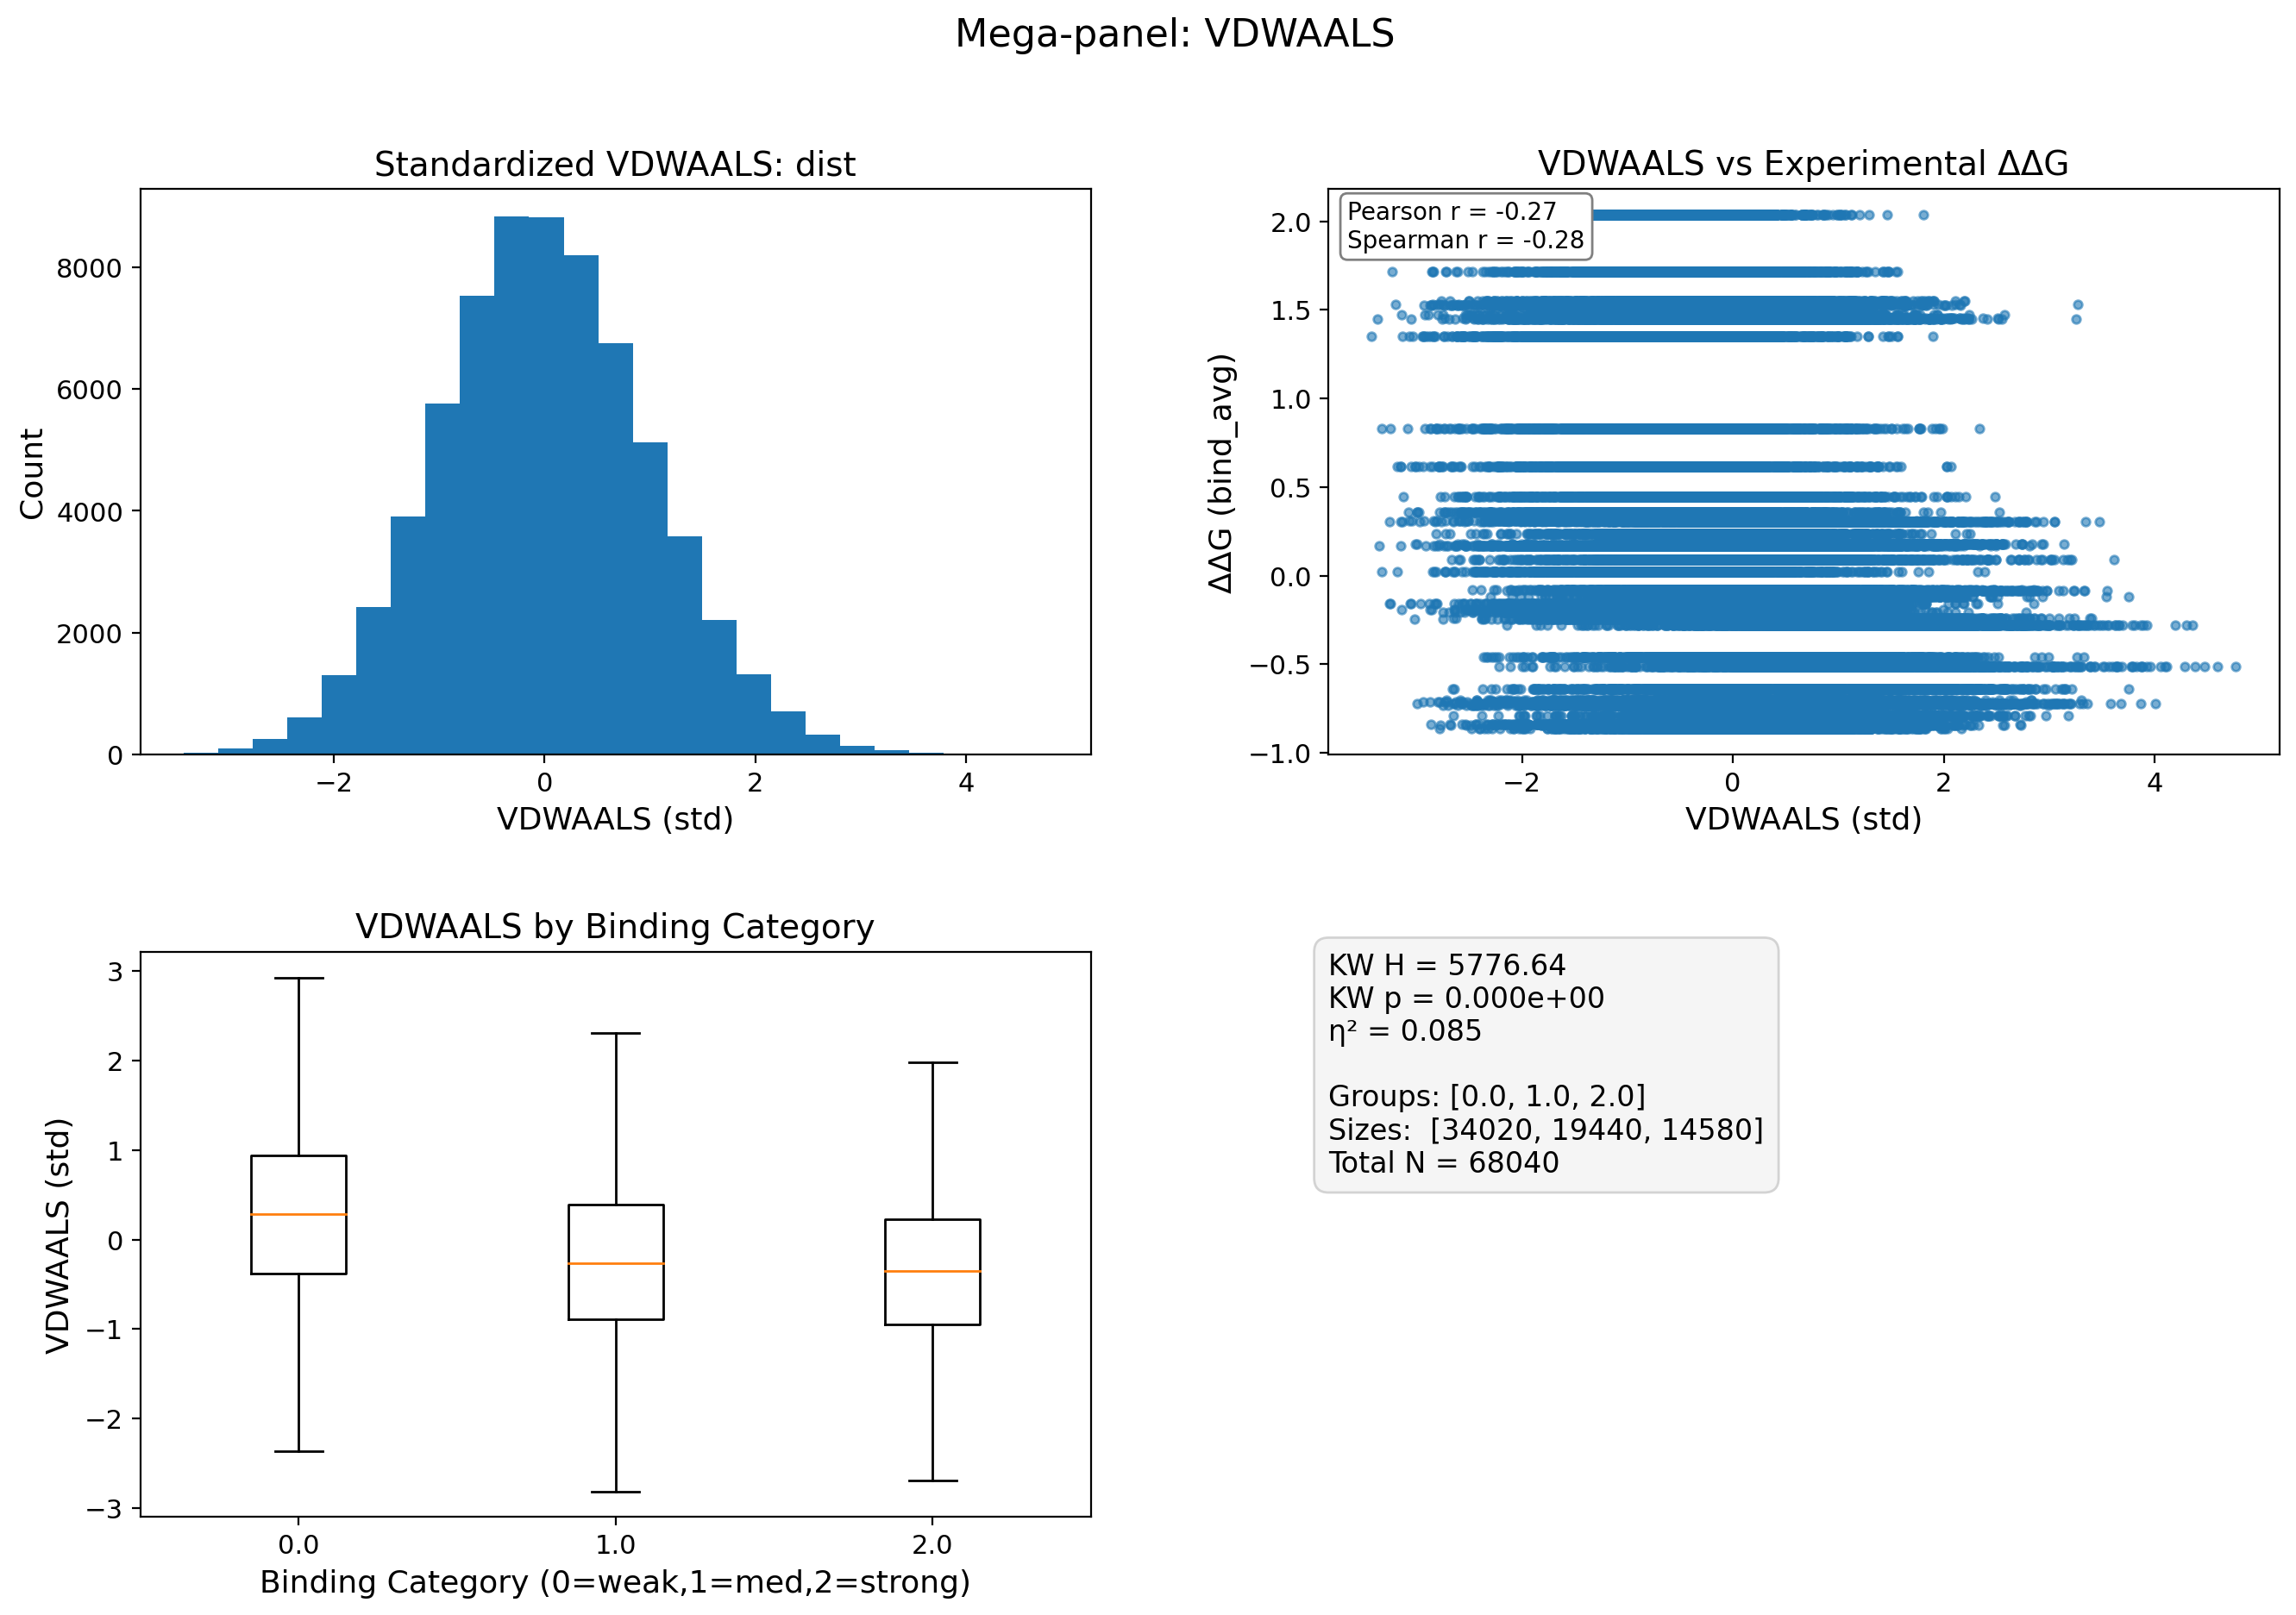

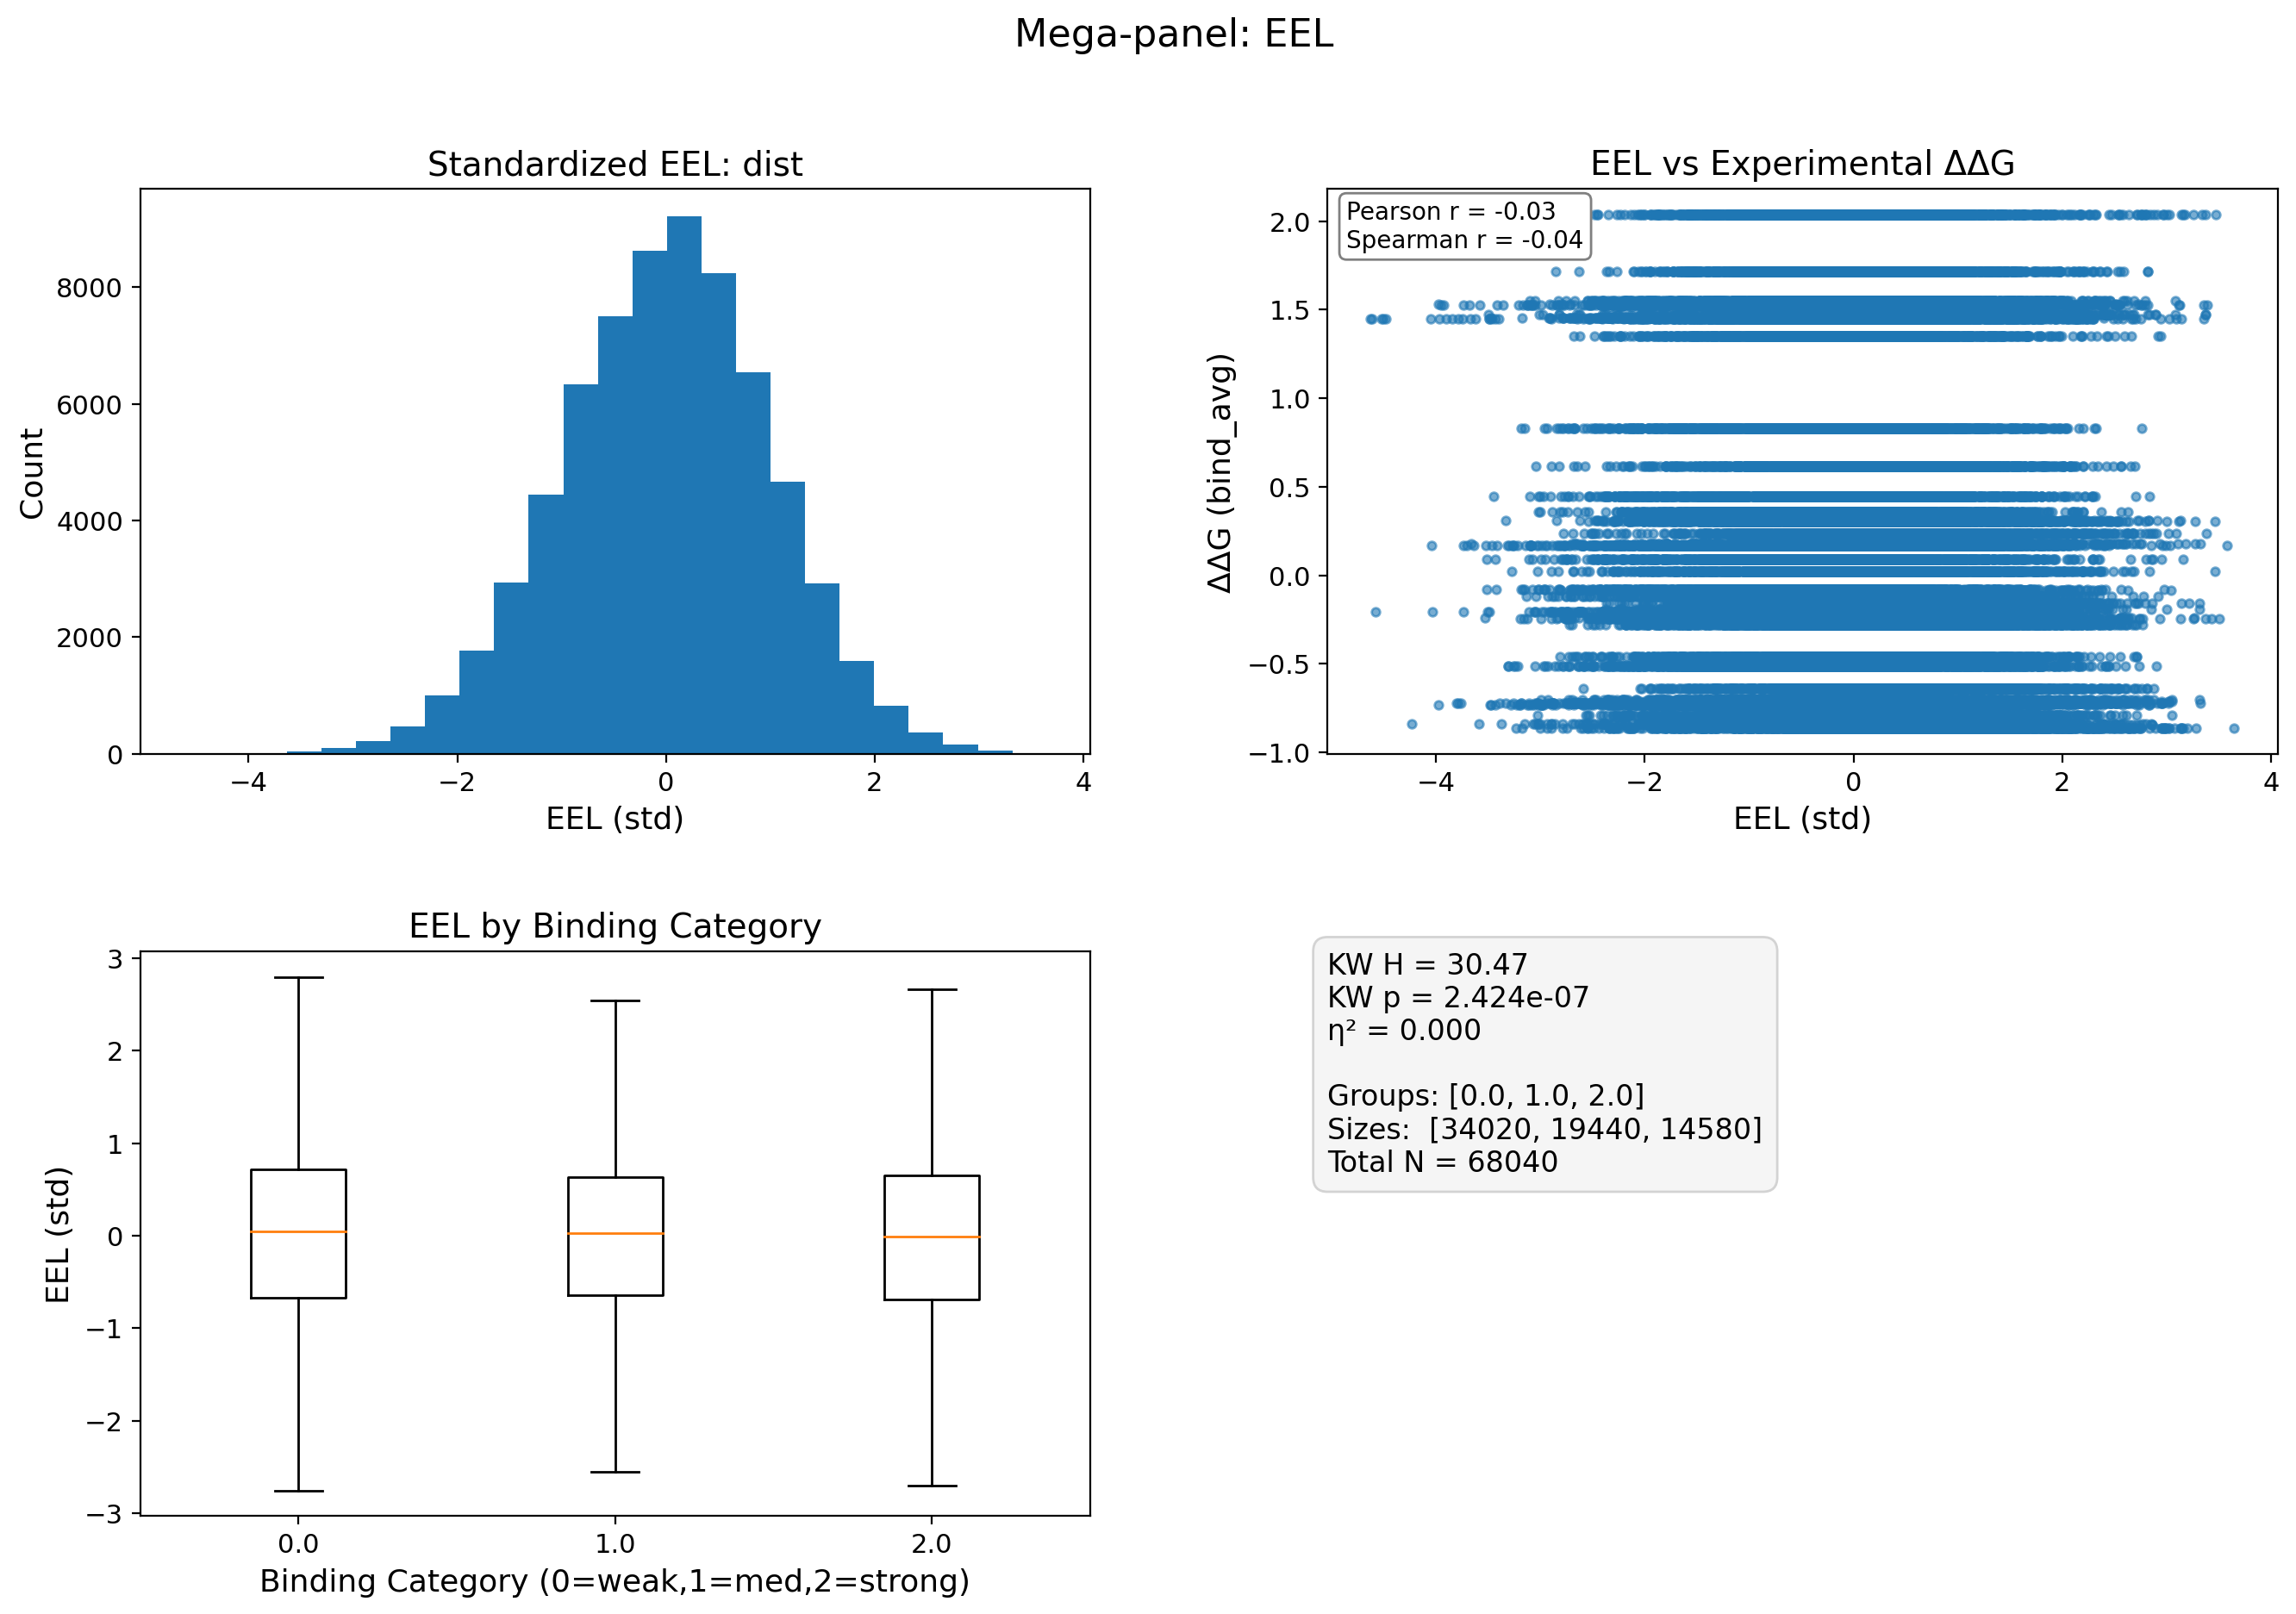

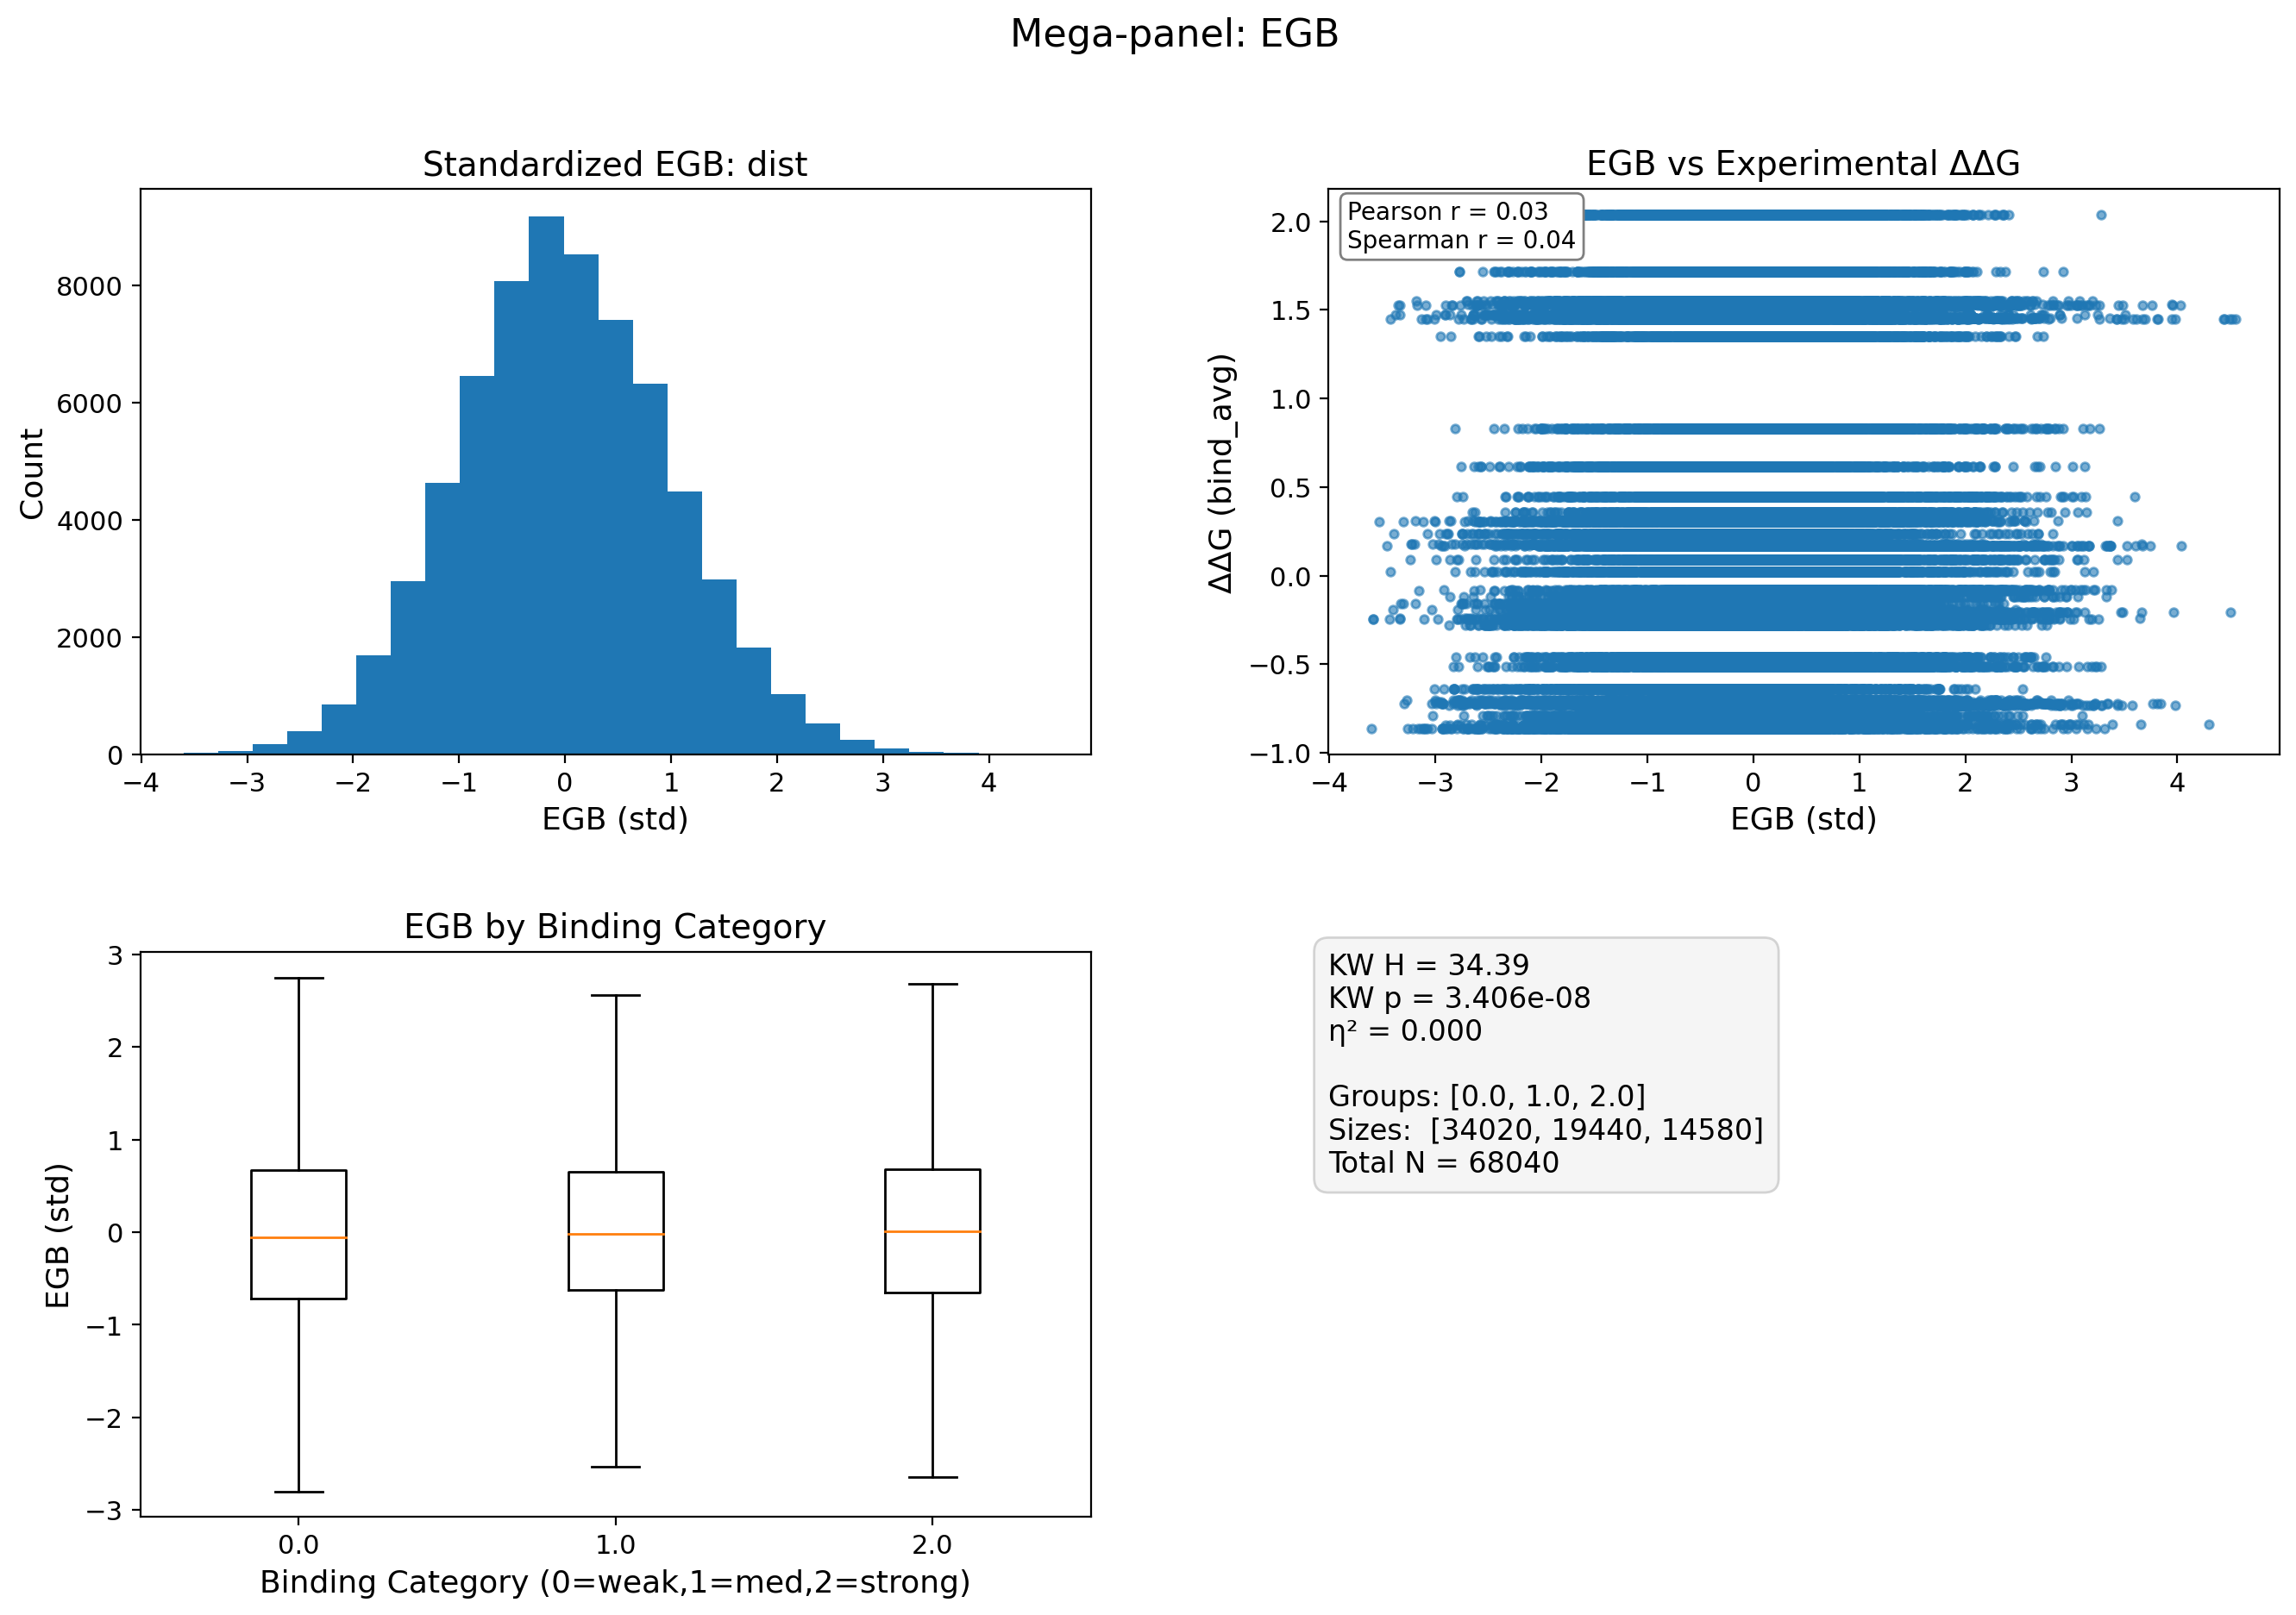

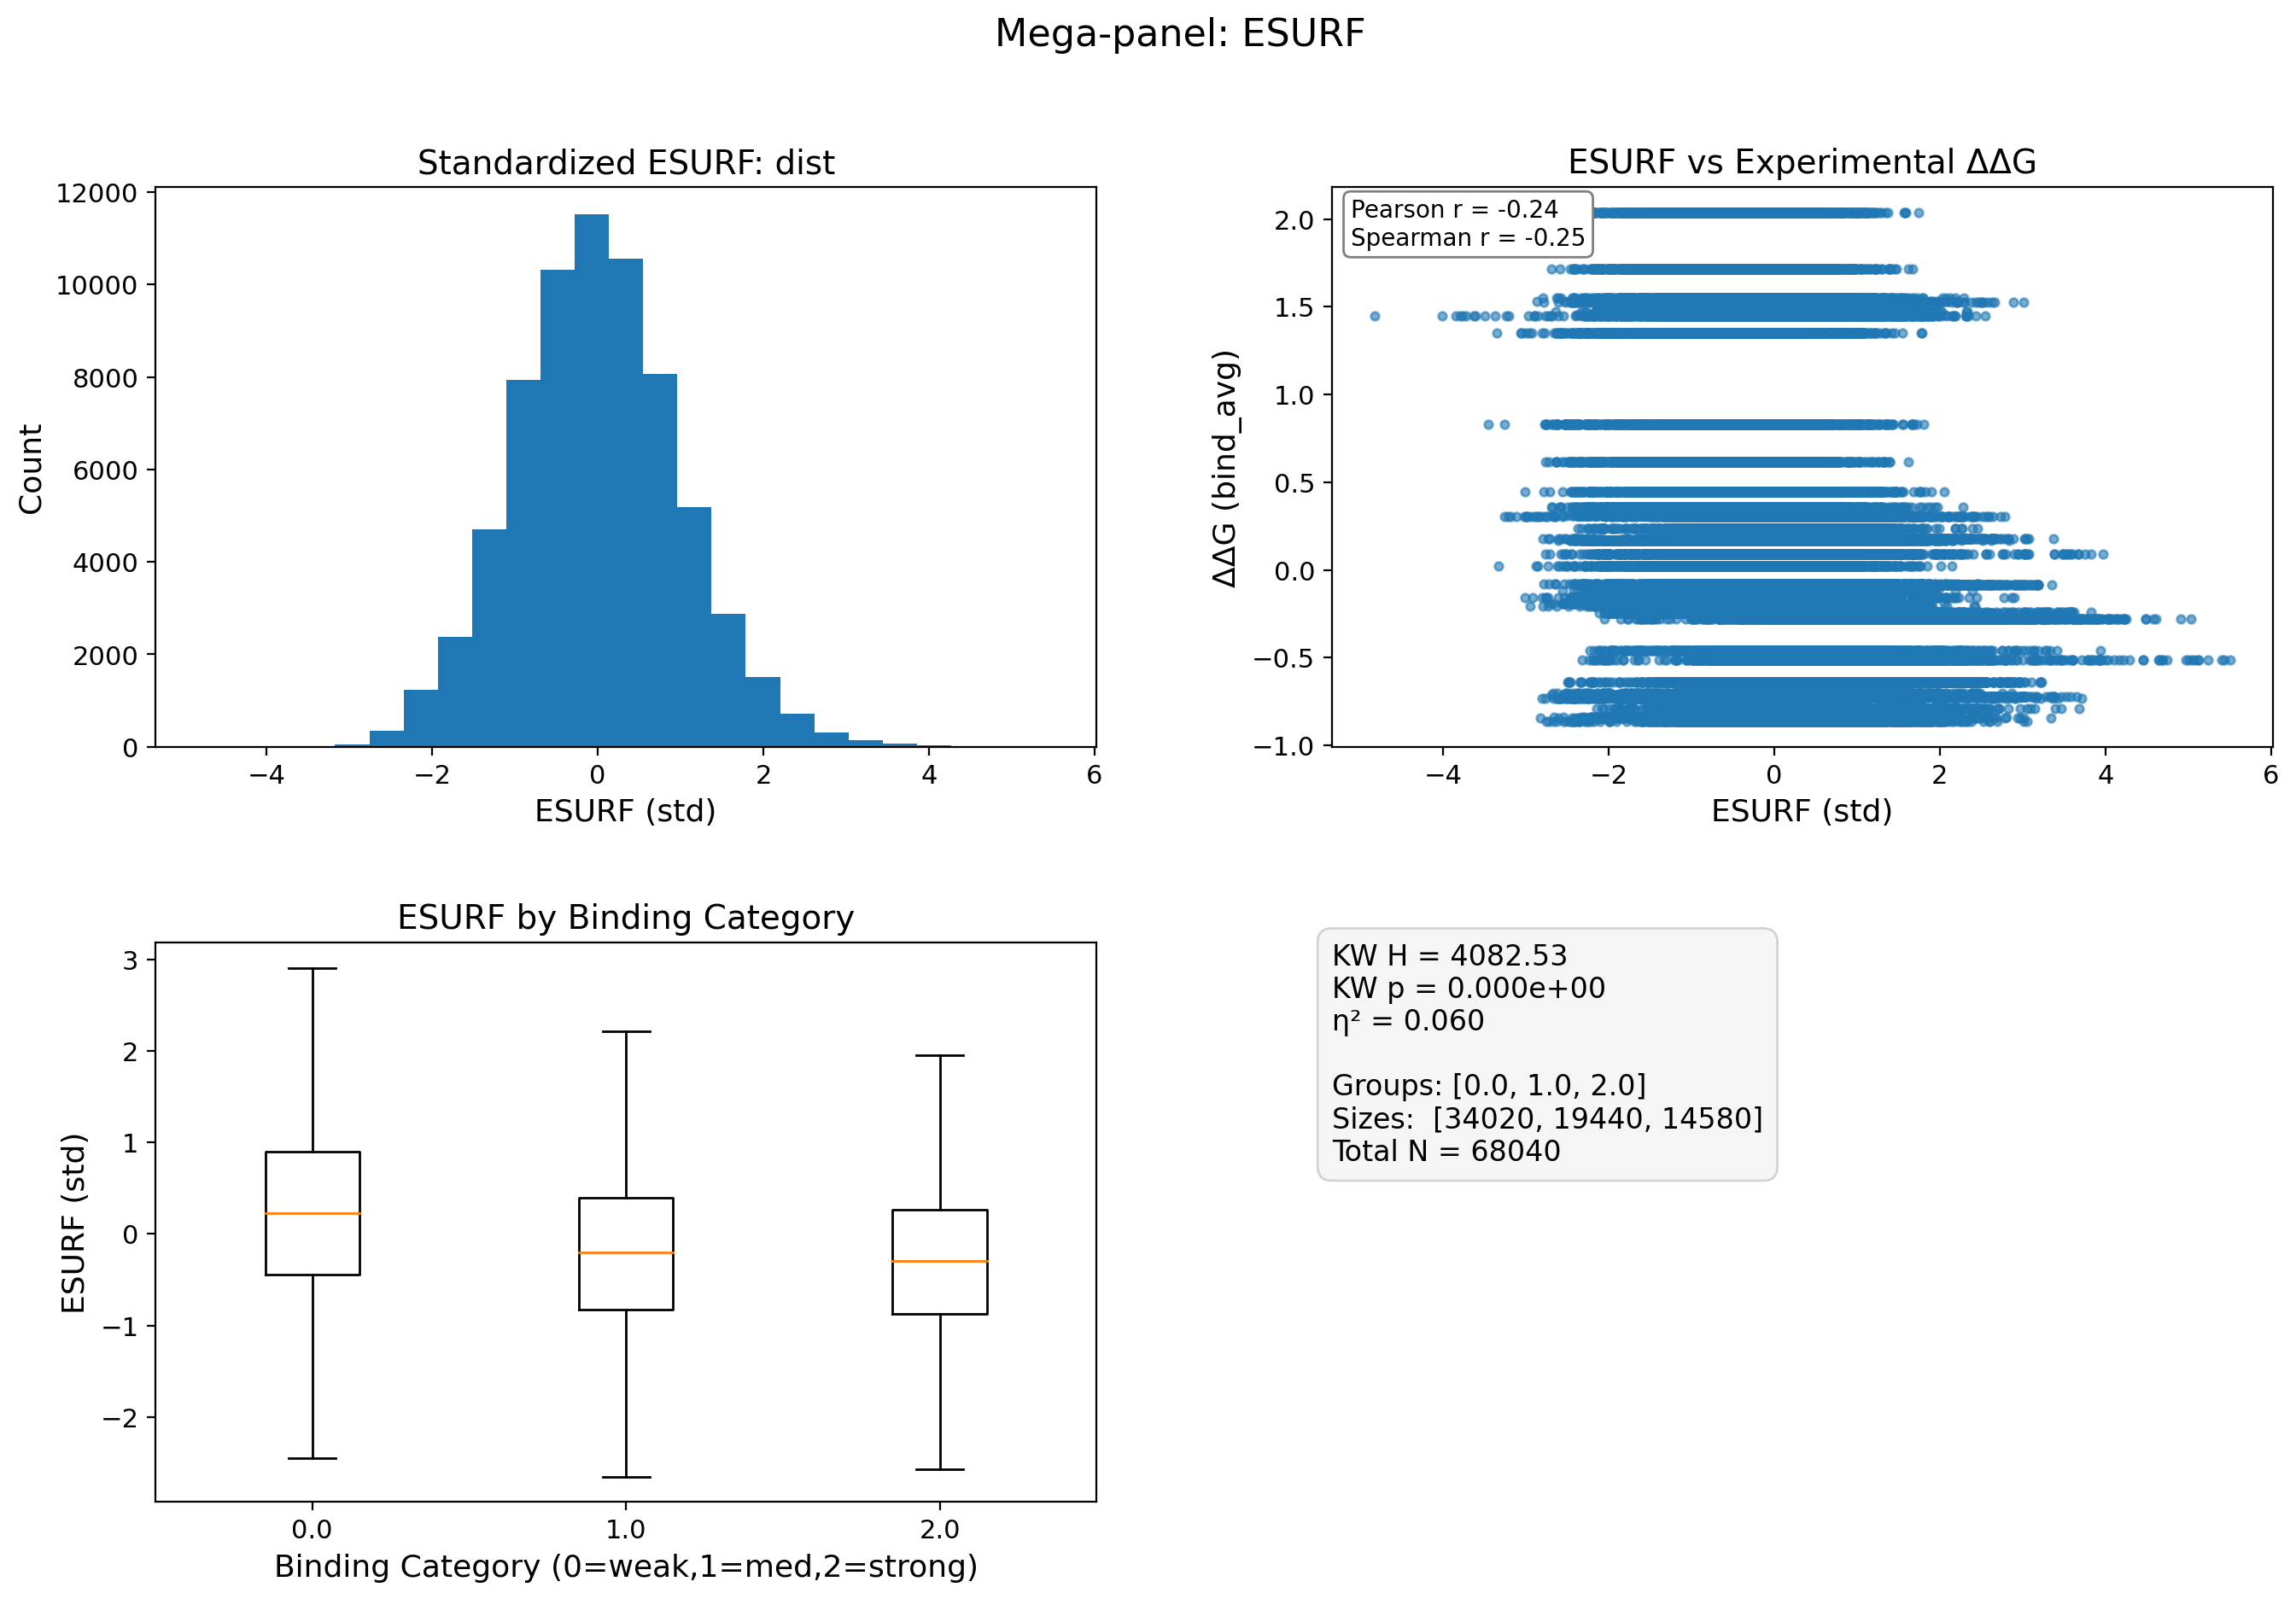

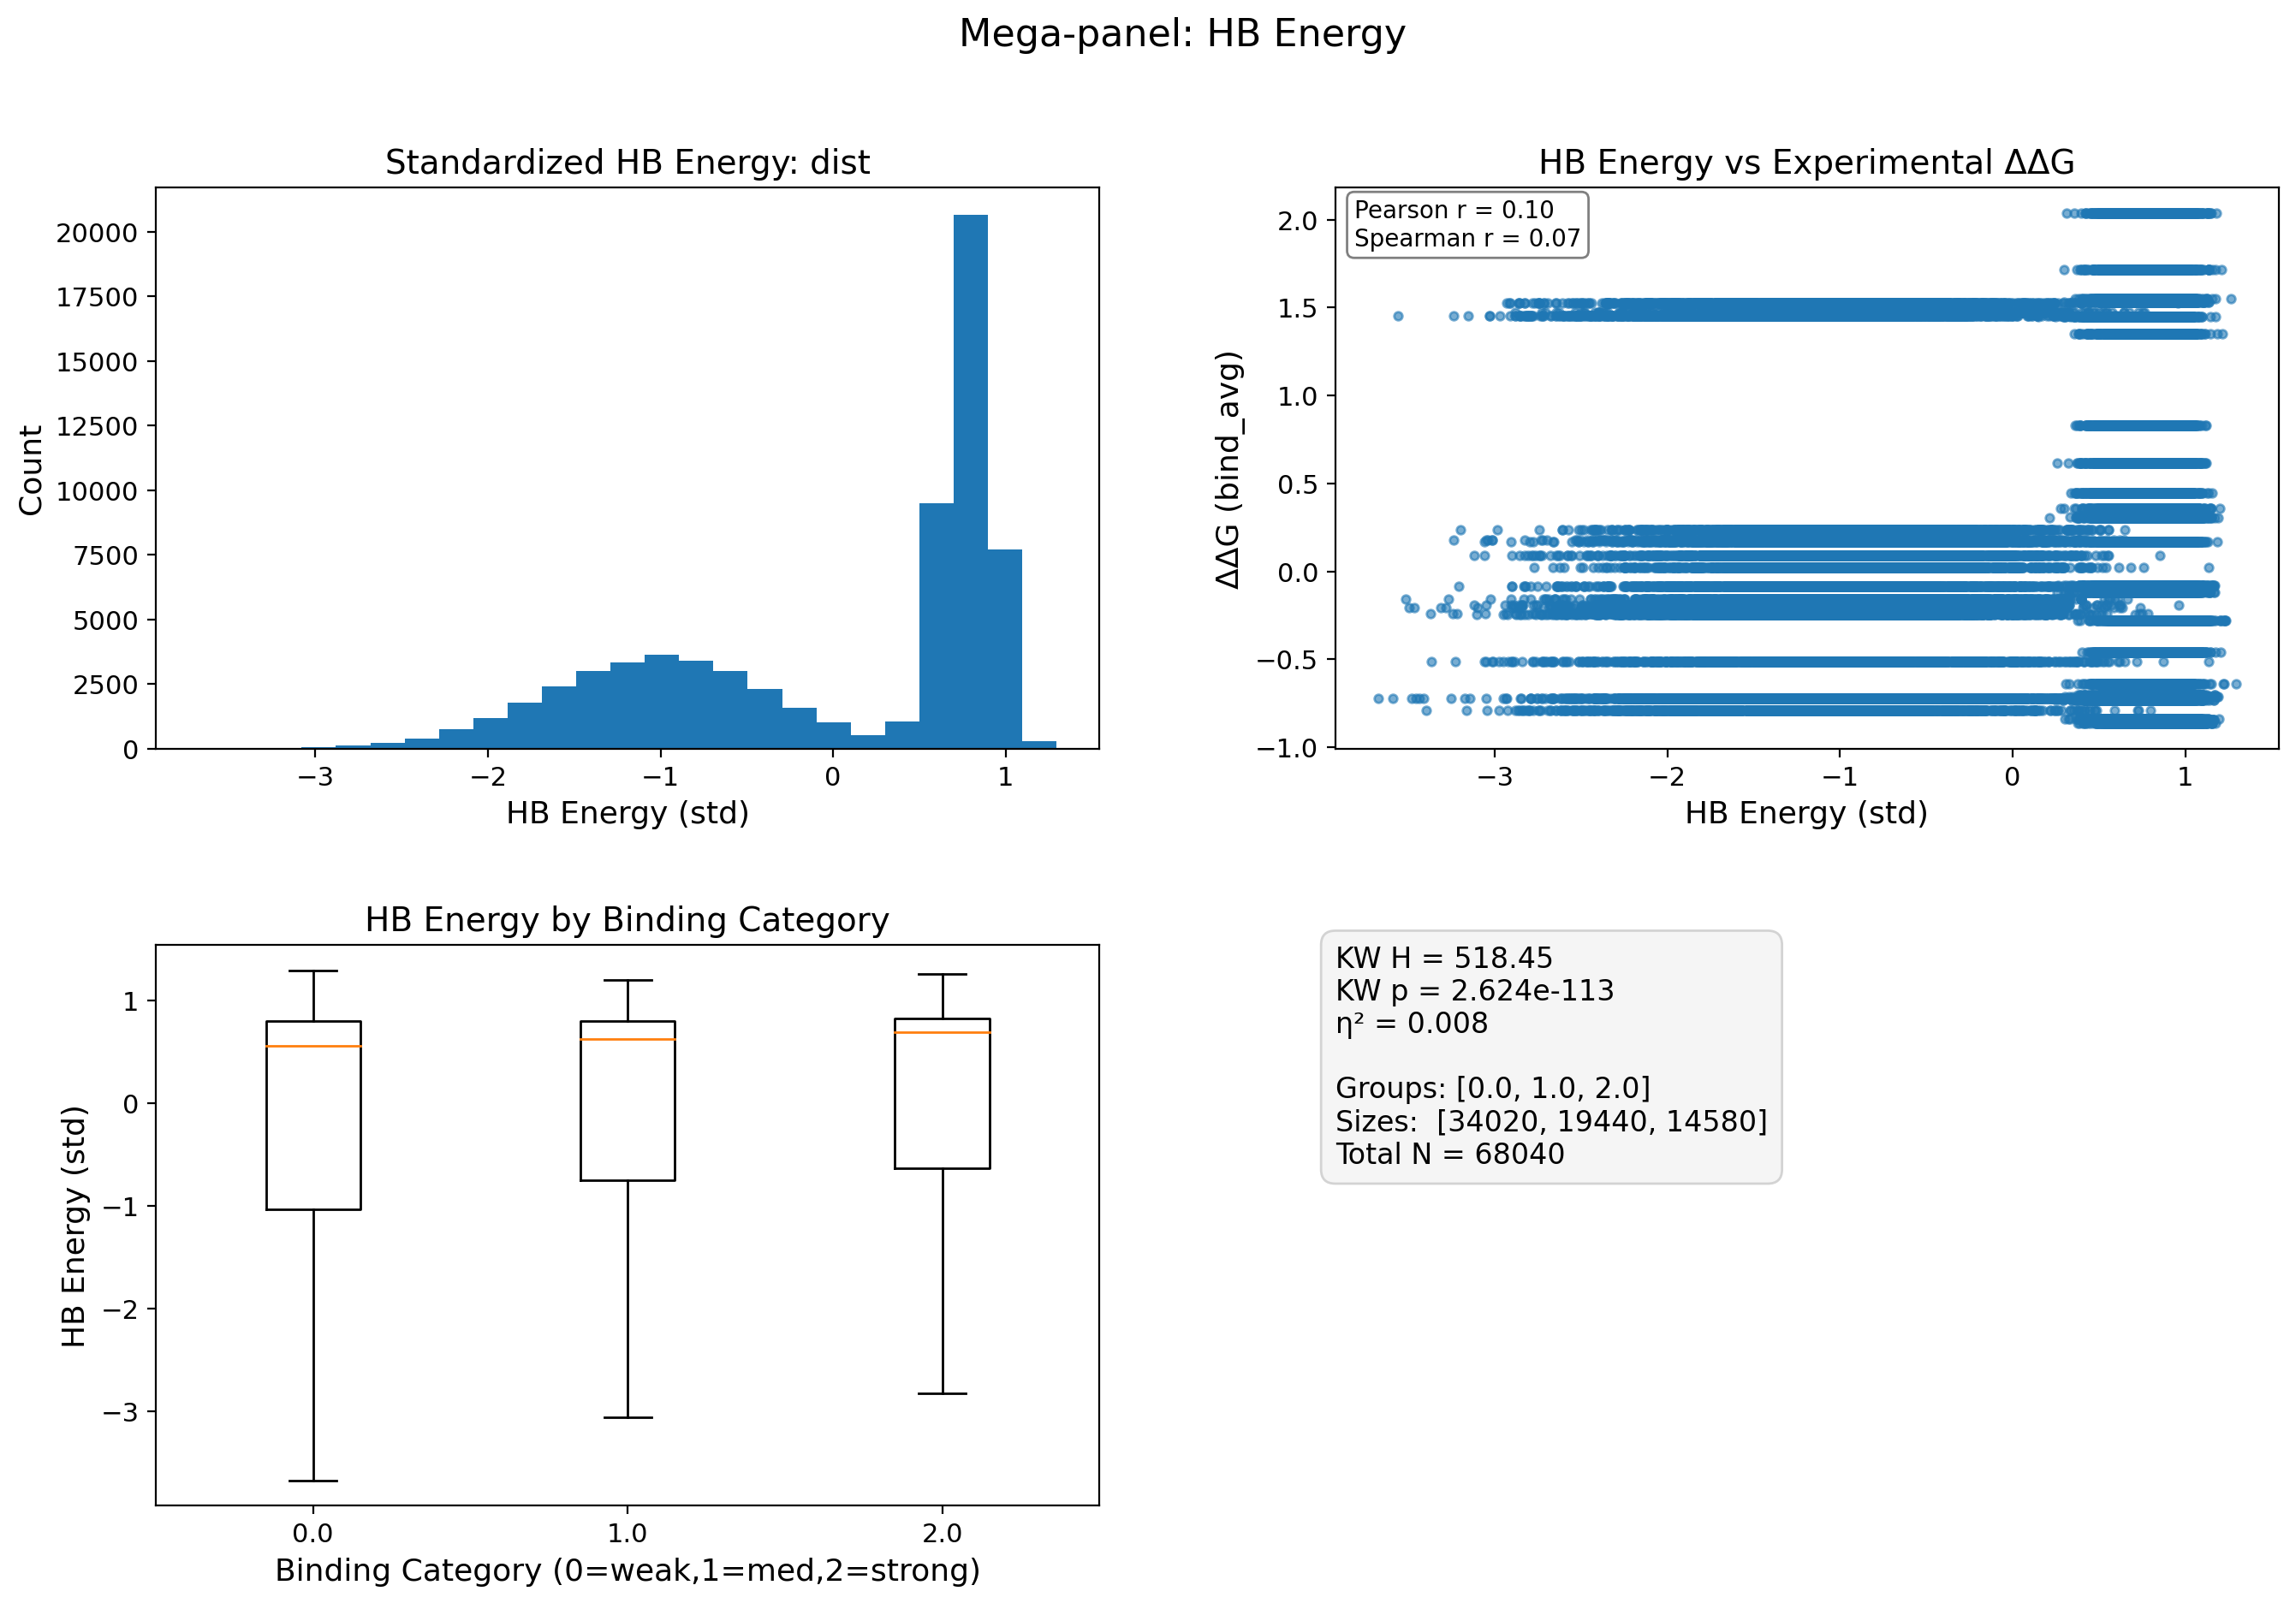

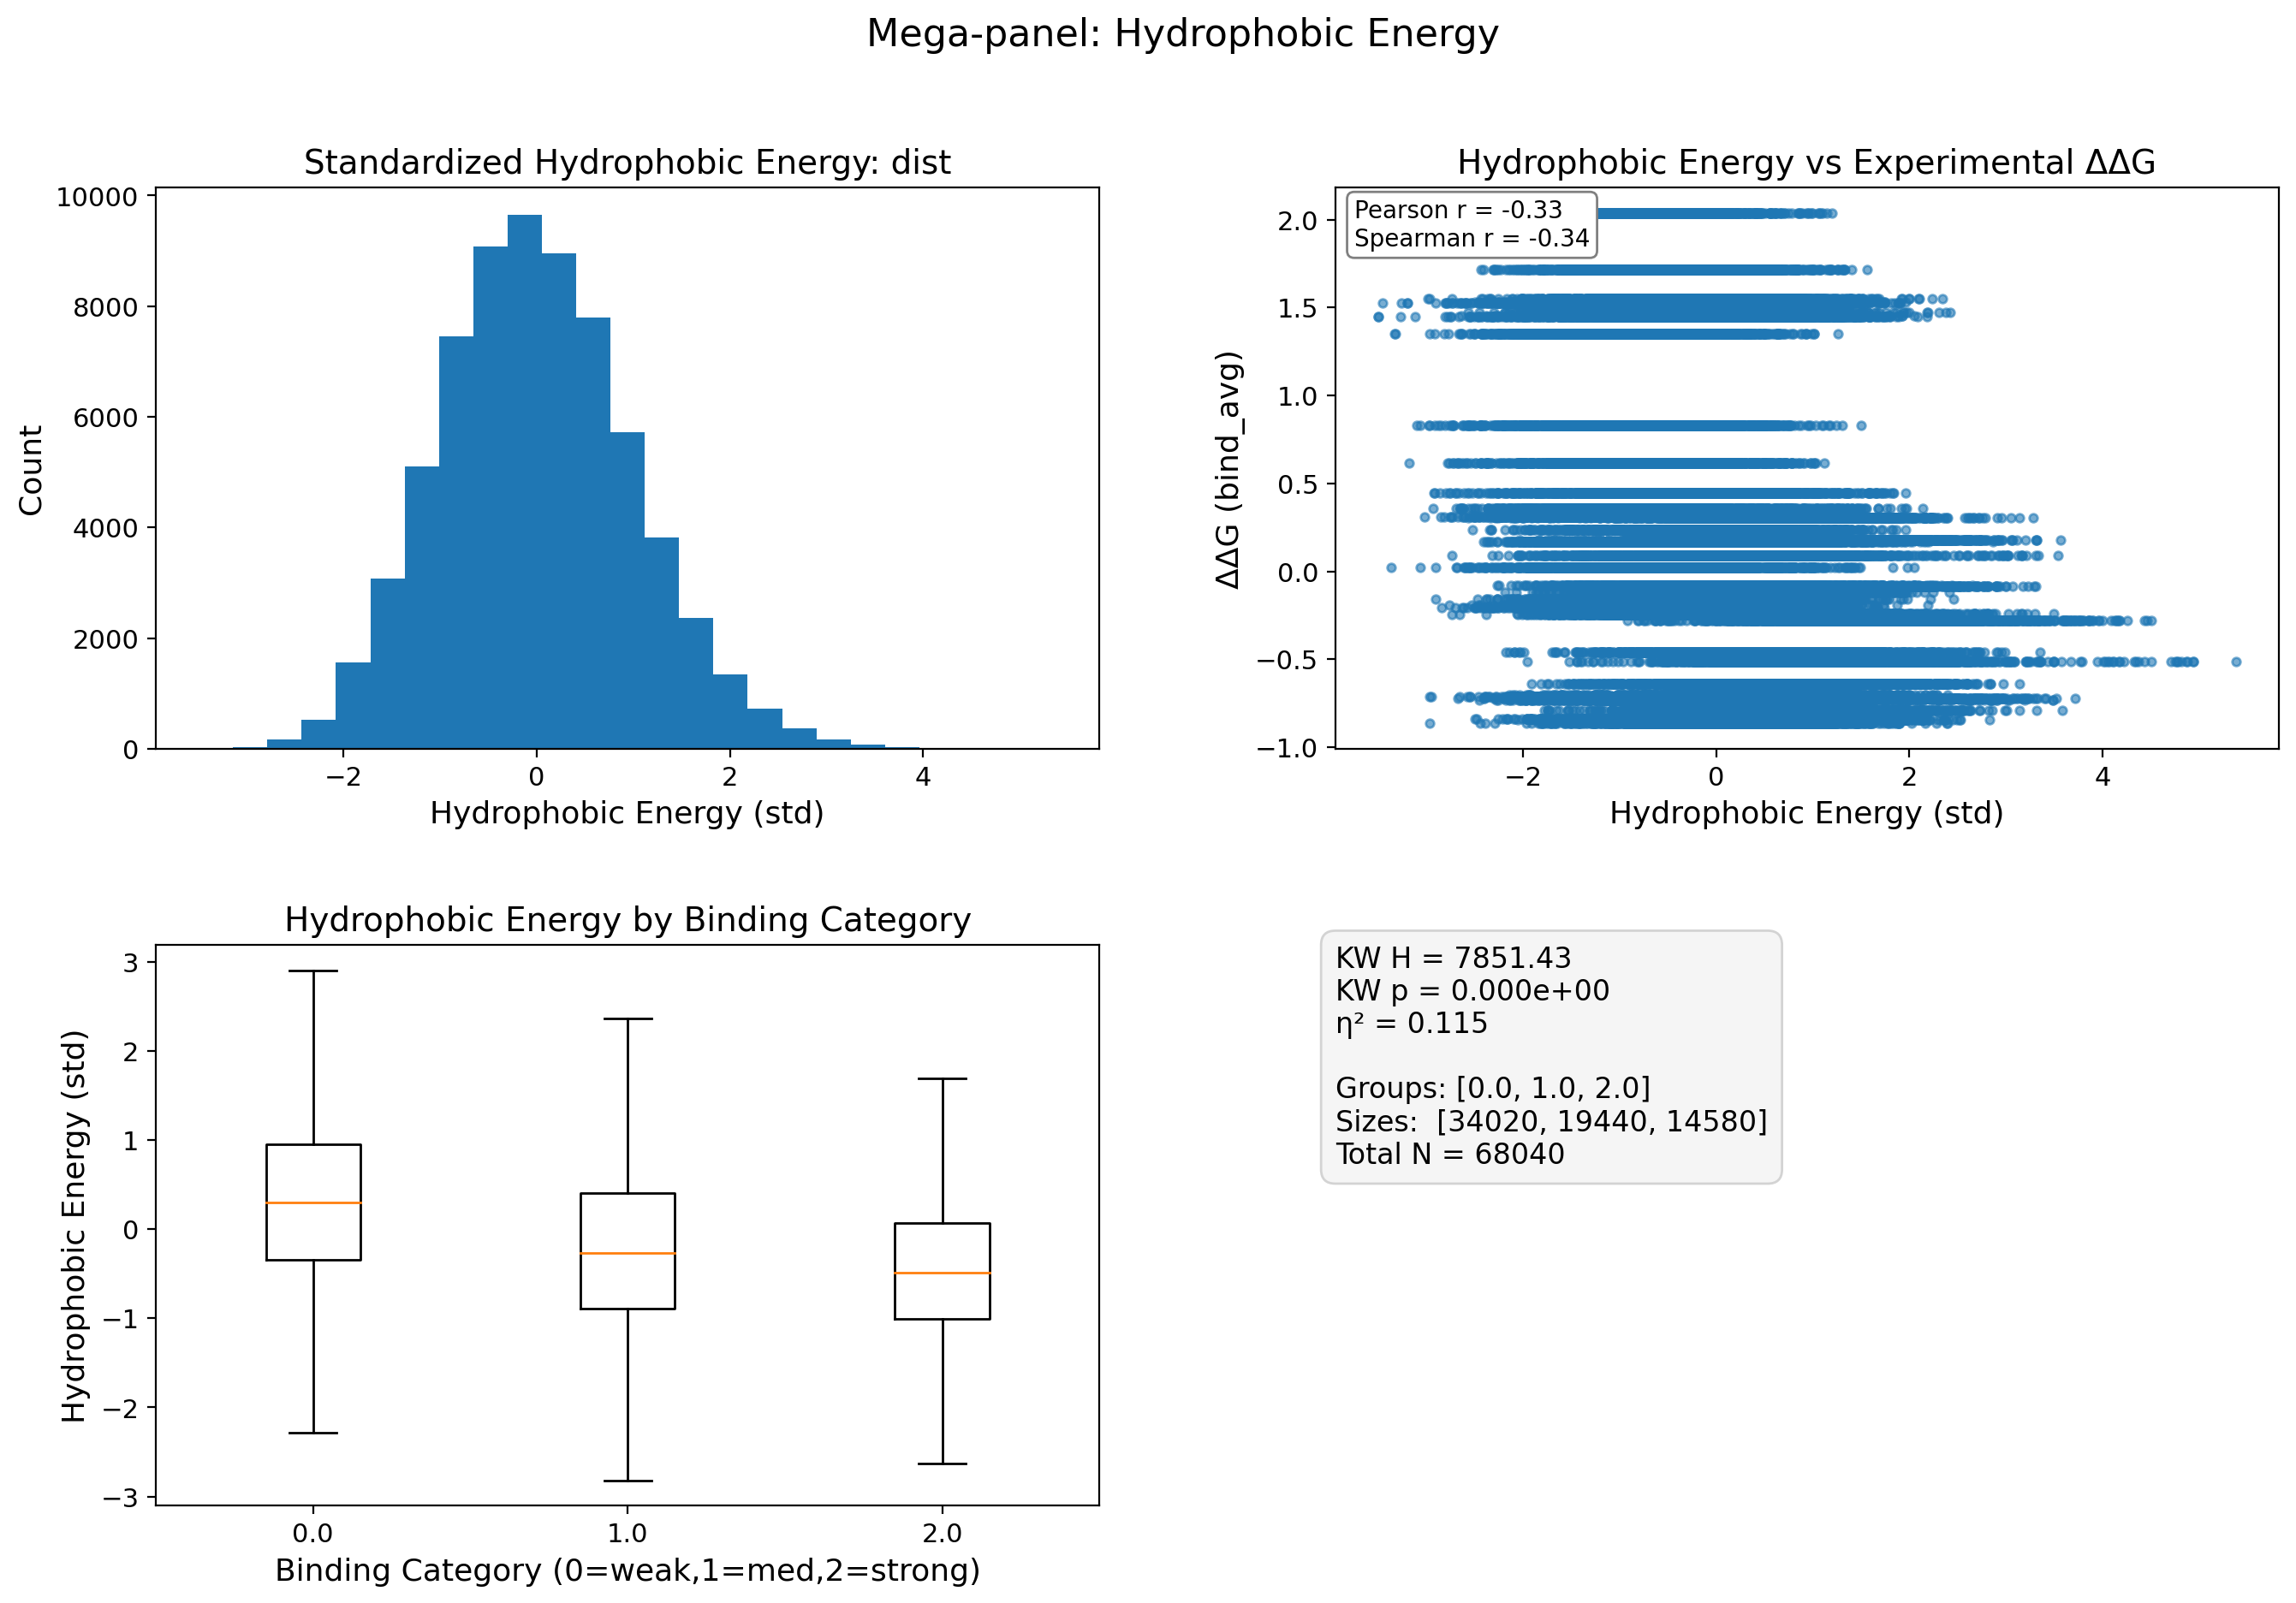

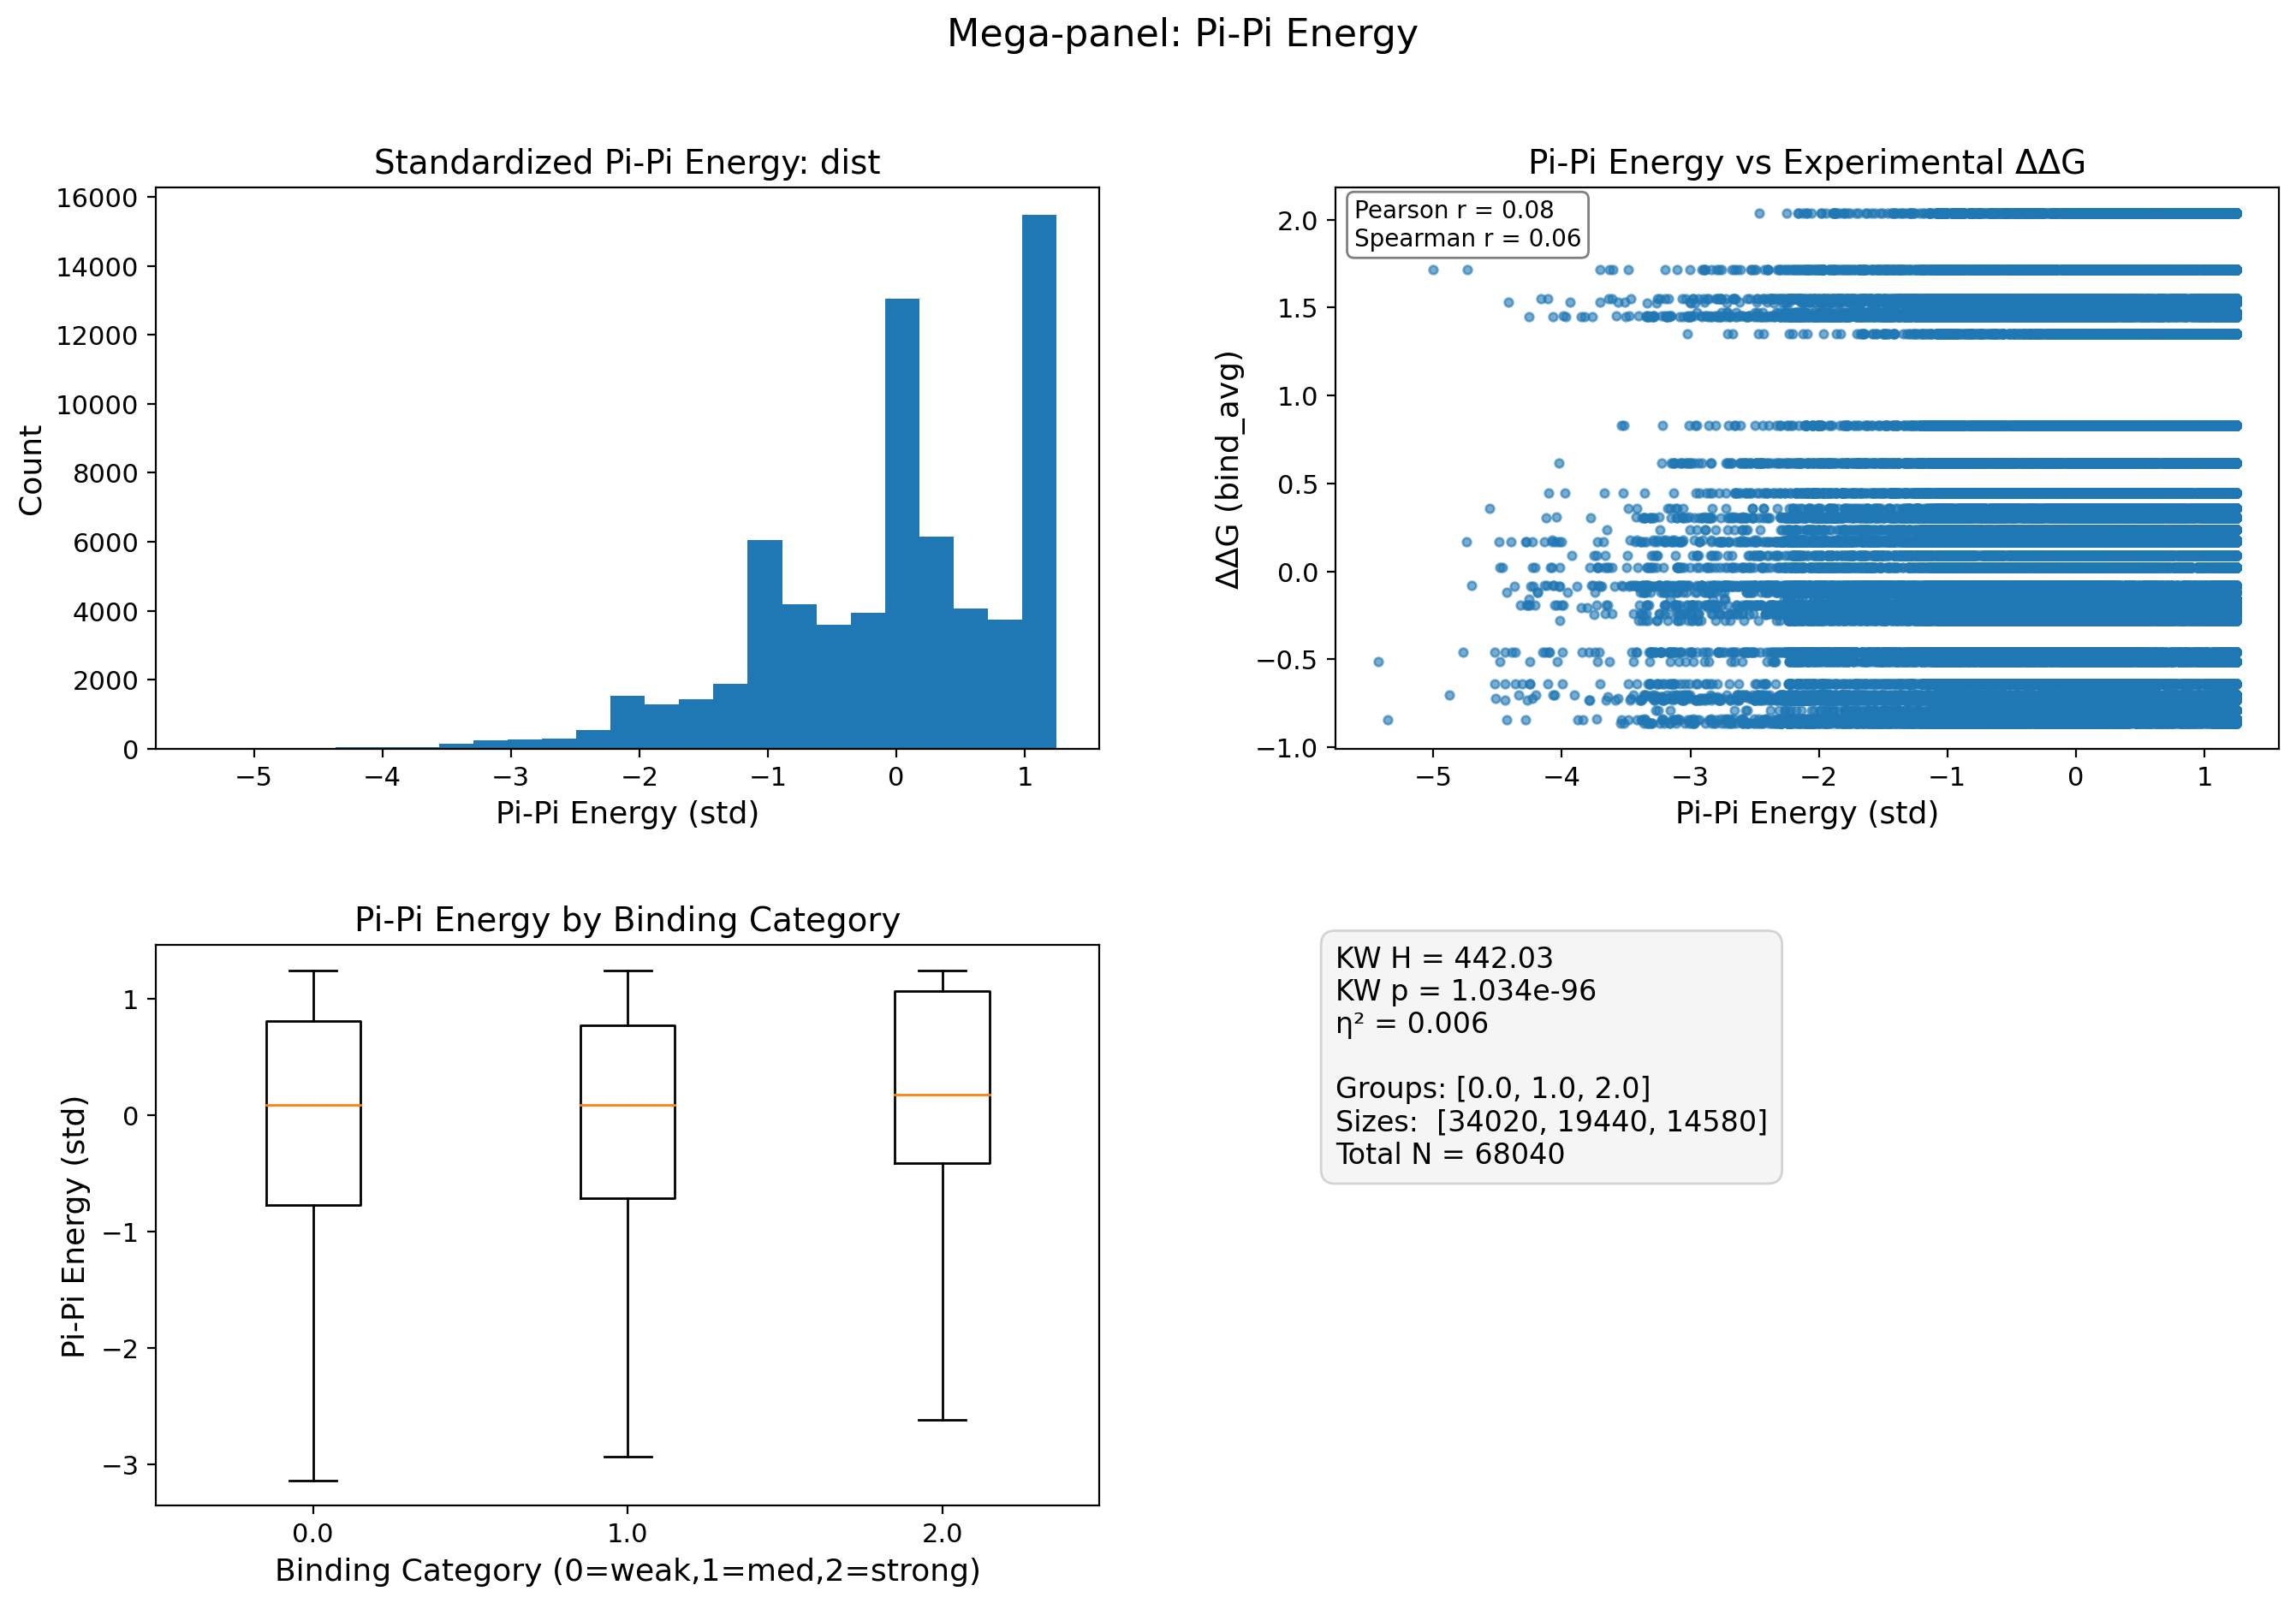

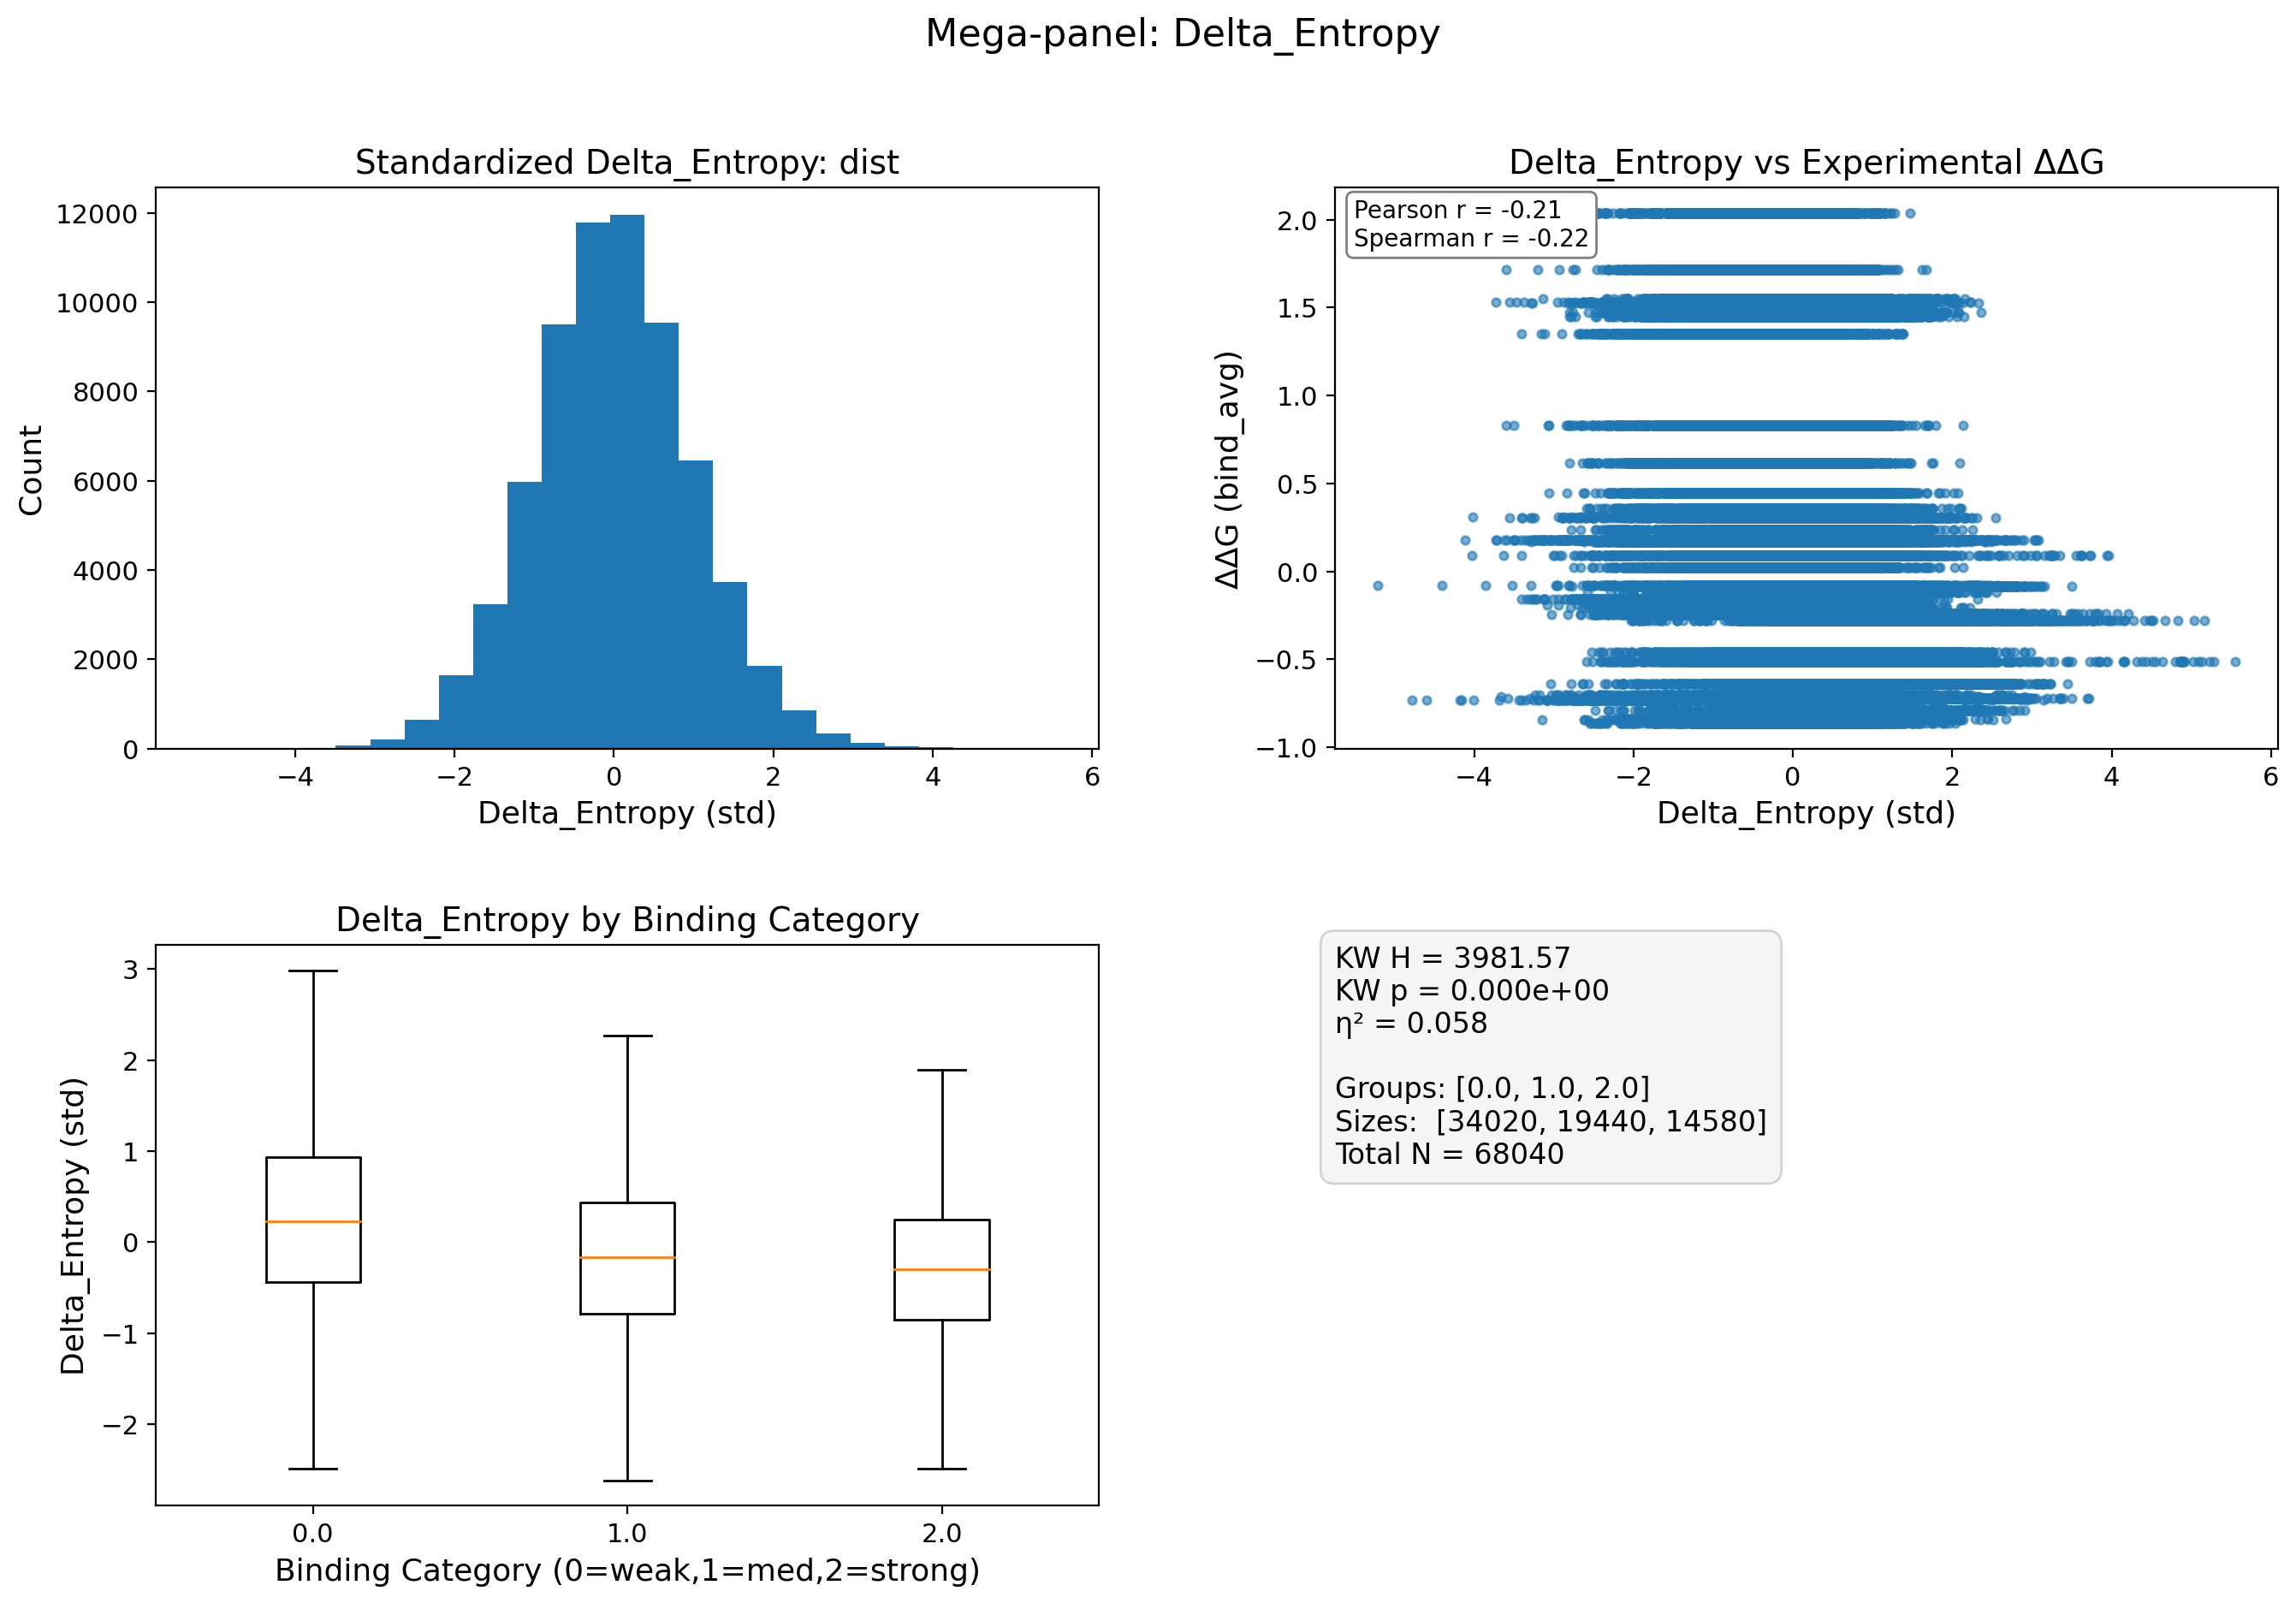

In [11]:
# EXAMPLE USAGE:
energy_terms = test1.drop(columns=['sequence','run']).columns
for term in energy_terms:
    plot_term_panel(df, term, save = False)

In [12]:
df

,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,...,binding_type,improving,VDWAALS_z_within,EEL_z_within,EGB_z_within,ESURF_z_within,HB Energy_z_within,Hydrophobic Energy_z_within,Pi-Pi Energy_z_within,Delta_Entropy_z_within
1620,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-236.997,-1869.660,1823.216,-35.292,-2.590101,-156.445725,-4.282747,-24.750849,...,1.0,0.0,-2.098662,1.000877,-0.968771,-1.871198,0.987601,-1.851775,-0.544505,-1.568460
1621,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-218.620,-1850.331,1807.831,-32.521,-2.977171,-142.709472,-7.240534,-25.235404,...,1.0,0.0,-1.051172,1.488413,-1.383411,-0.591170,0.500932,-0.581041,-1.733102,-1.822315
1622,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-232.611,-1878.075,1834.181,-34.170,-3.105868,-145.088977,-8.856276,-25.124940,...,1.0,0.0,-1.848660,0.788625,-0.673254,-1.352904,0.339121,-0.801168,-2.382393,-1.764444
1623,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-203.677,-1870.595,1823.641,-32.402,-3.414769,-150.961716,-5.338670,-23.079573,...,1.0,0.0,-0.199419,0.977294,-0.957317,-0.536200,-0.049265,-1.344452,-0.968832,-0.692889
1624,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-212.279,-1864.730,1820.462,-31.858,-3.571942,-146.583284,-7.171679,-22.812241,...,1.0,0.0,-0.689734,1.125227,-1.042994,-0.284906,-0.246880,-0.939406,-1.705432,-0.552835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262435,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-202.283,-1879.826,1832.379,-32.929,-14.839736,-146.069103,-8.120329,-22.481285,...,0.0,1.0,0.244156,0.243135,-0.284102,-0.411765,-0.208899,-0.723027,-2.632854,0.048261
262436,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-194.599,-1894.990,1847.186,-32.980,-12.082321,-142.591876,-9.019913,-22.615403,...,0.0,1.0,0.664885,-0.179567,0.159236,-0.435191,0.525069,-0.393951,-3.045750,-0.017187
262437,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-201.025,-1877.378,1832.770,-30.974,-11.361504,-133.609931,-1.746638,-23.680611,...,0.0,1.0,0.313037,0.311373,-0.272395,0.486227,0.716936,0.456077,0.292580,-0.536993
262438,TTAGAACCTCAACCTCCTCTGCAAAATGGAGCTGAC,20,-208.522,-1861.670,1816.586,-32.079,-16.003776,-139.845659,-0.000942,-21.846114,...,0.0,1.0,-0.097453,0.749239,-0.756962,-0.021334,-0.518743,-0.134056,1.093829,0.358216


## Correlation Heatmap

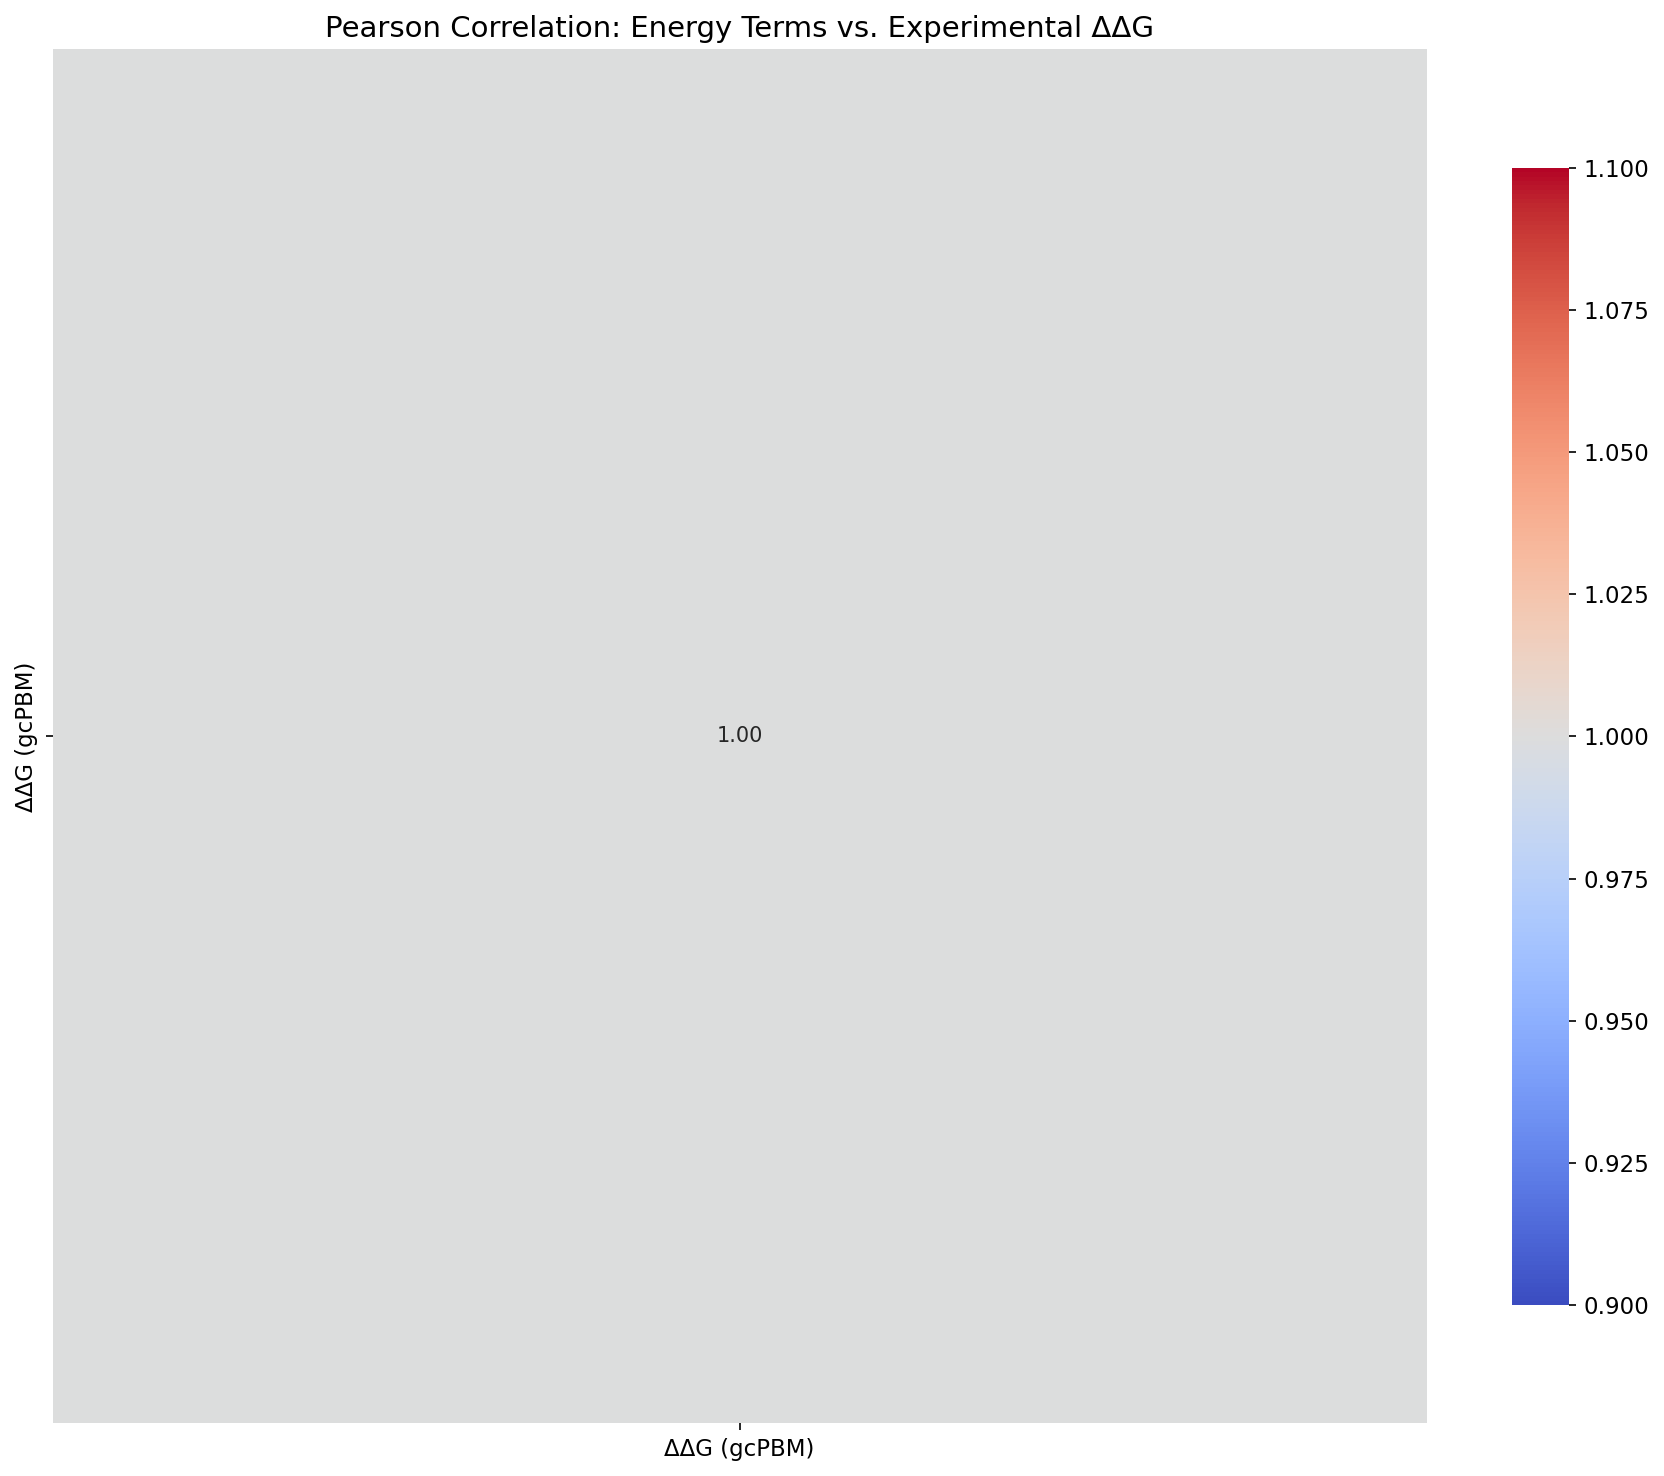

In [13]:
# 4) Correlation Heatmap of all standardized energy terms vs. experimental ΔΔG
# -----------------------------------------------------------------------------
# Build list of standardized columns that exist in df
std_cols = [f"{t} (std)" for t in energy_terms]
cols_for_corr = [c for c in std_cols + ["bind_avg"] if c in df.columns]

# Compute Pearson correlation matrix
corr = df[cols_for_corr].corr(method="pearson")

# Relabel for display
label_map = {c: ("ΔΔG (gcPBM)" if c=="bind_avg" else c.replace(" (std)","")) for c in corr.columns}
corr = corr.rename(columns=label_map, index=label_map)

plt.figure(figsize=(12,10), dpi=150)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Pearson Correlation: Energy Terms vs. Experimental ΔΔG")
plt.tight_layout()
plt.show()

## Putting all Plots together   

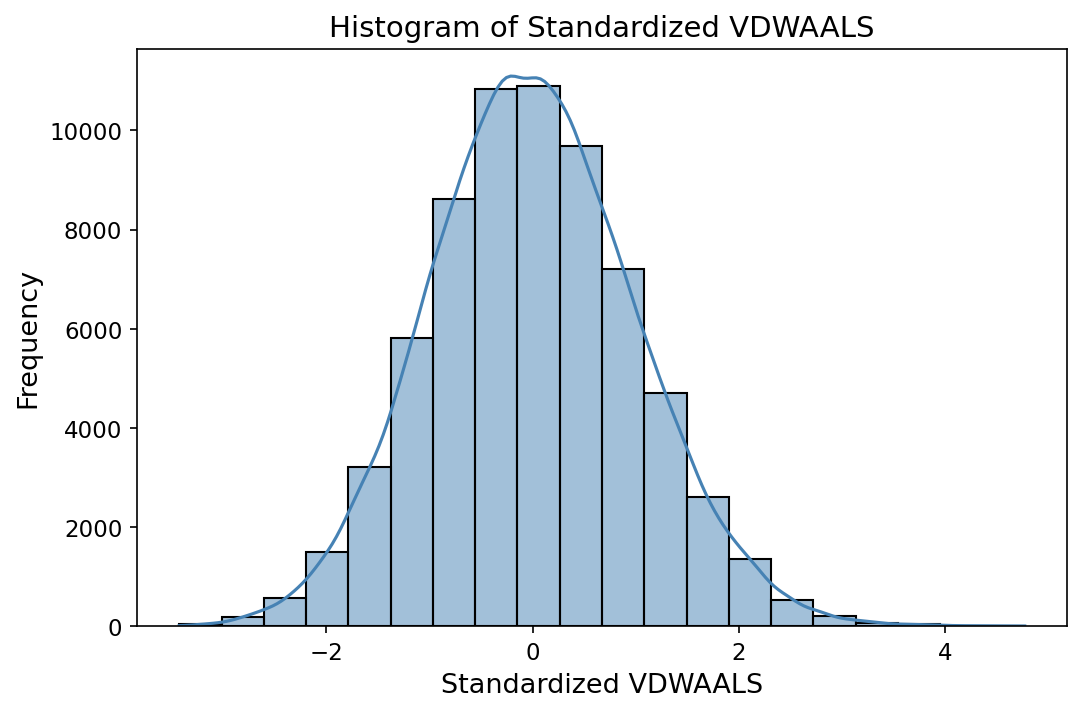

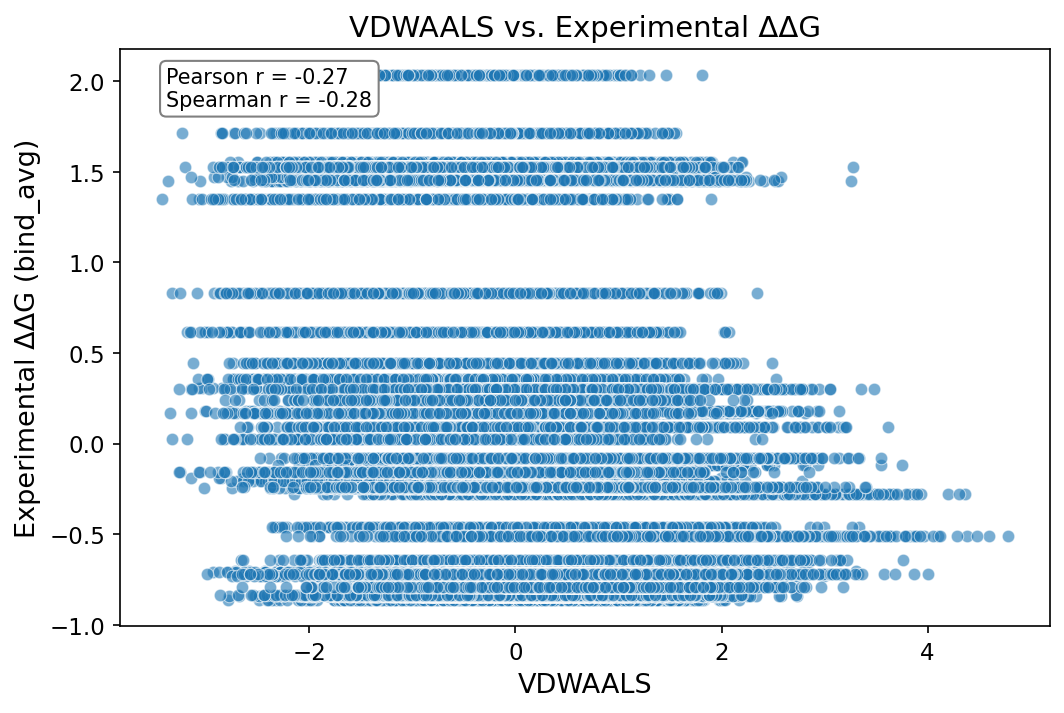

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


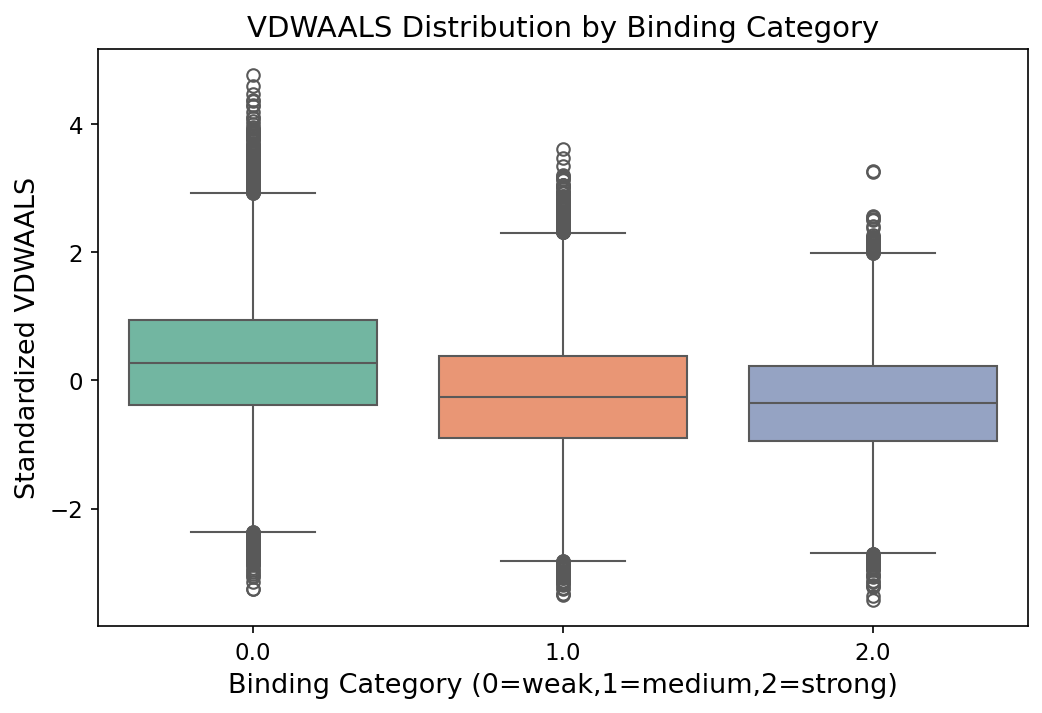

Term: VDWAALS
 • Avg. bootstrapped KW p-value: 3.664e-19
 • Full KW H-stat=5776.64, p-value=0.000e+00, η²=0.085
--------------------------------------------------


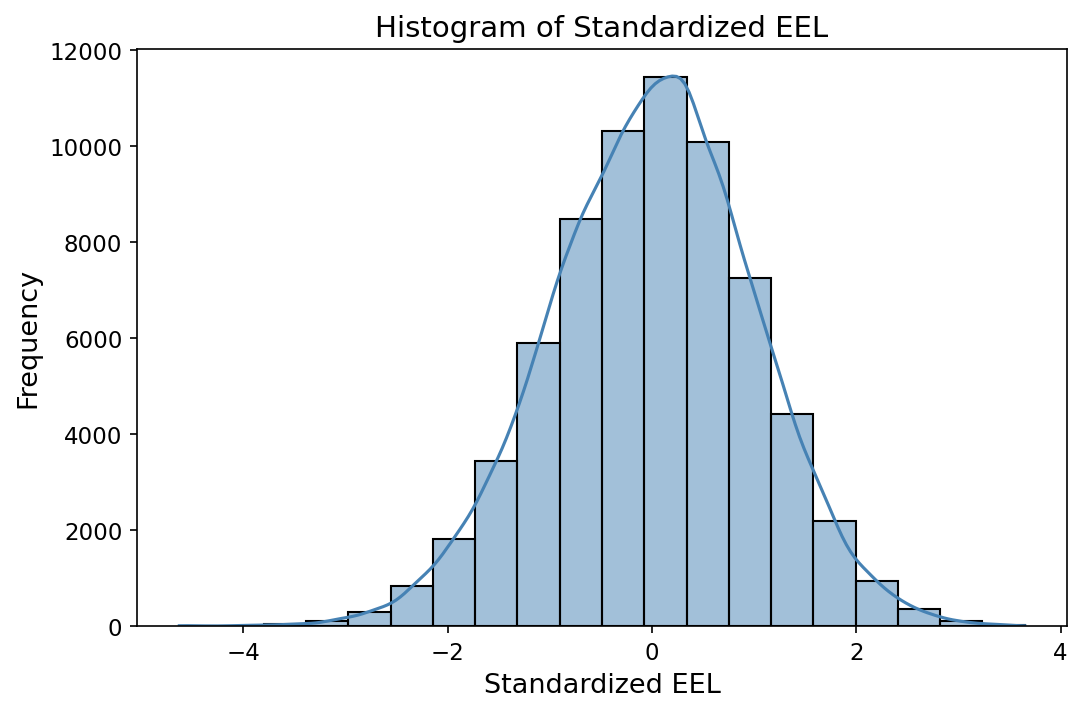

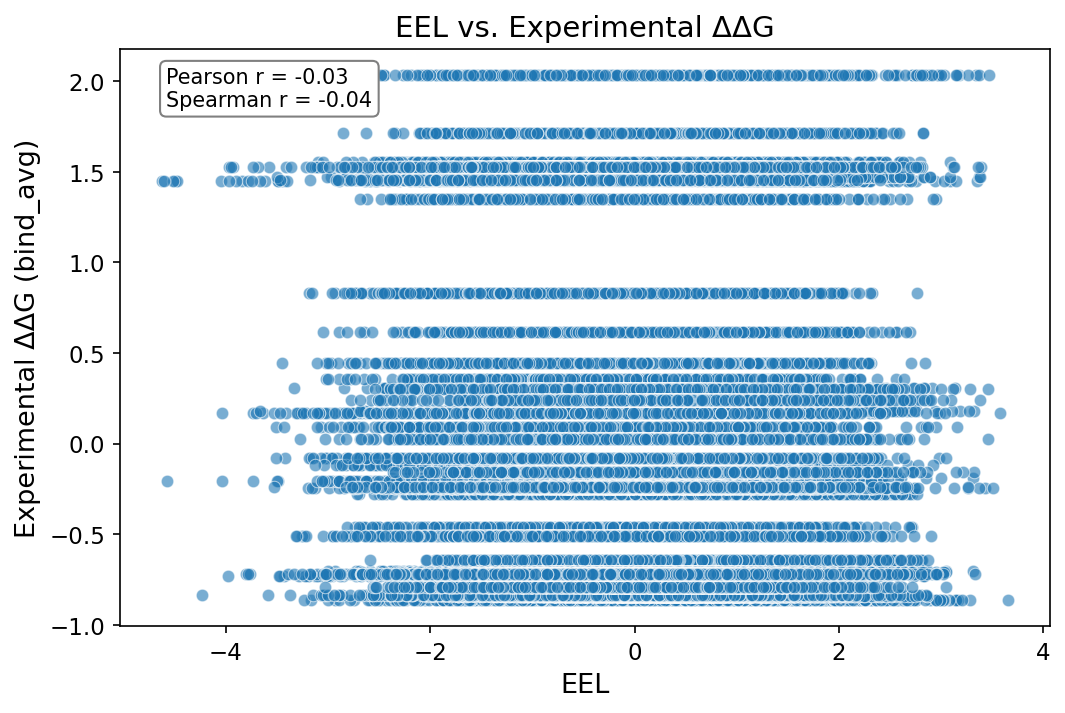

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


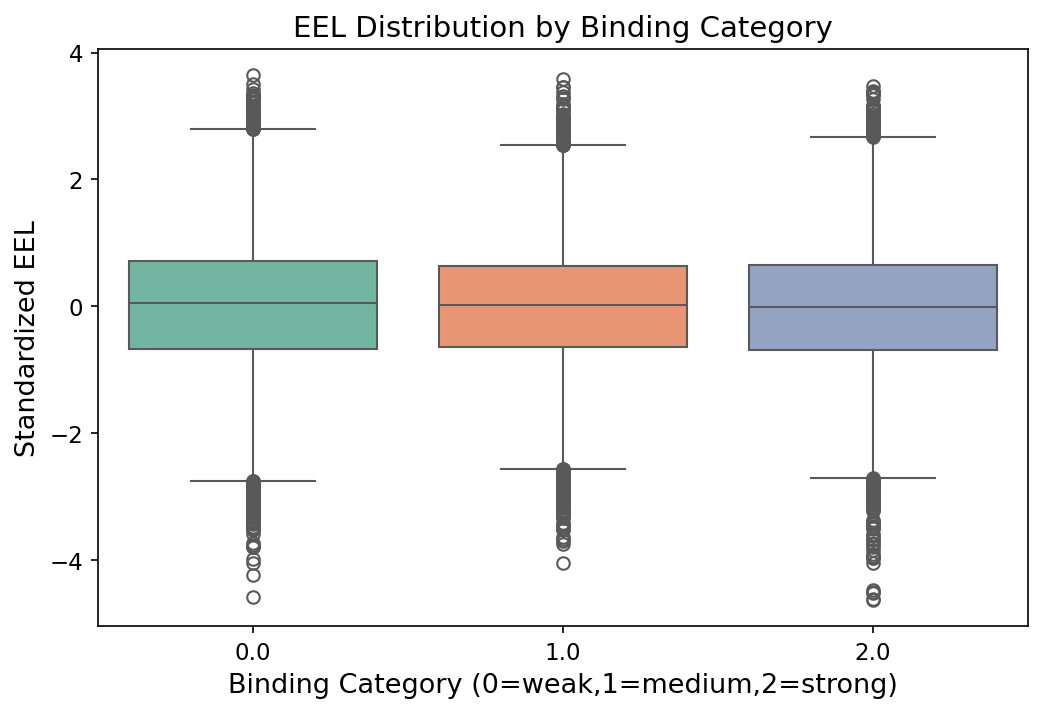

Term: EEL
 • Avg. bootstrapped KW p-value: 3.632e-01
 • Full KW H-stat=30.47, p-value=2.424e-07, η²=0.000
--------------------------------------------------


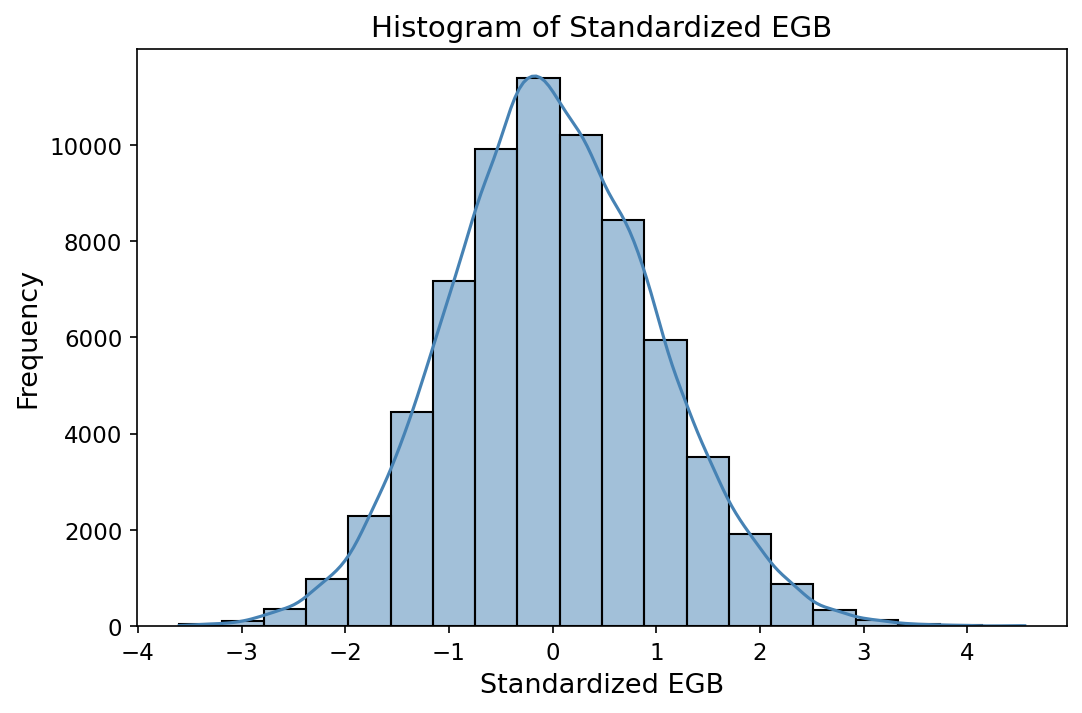

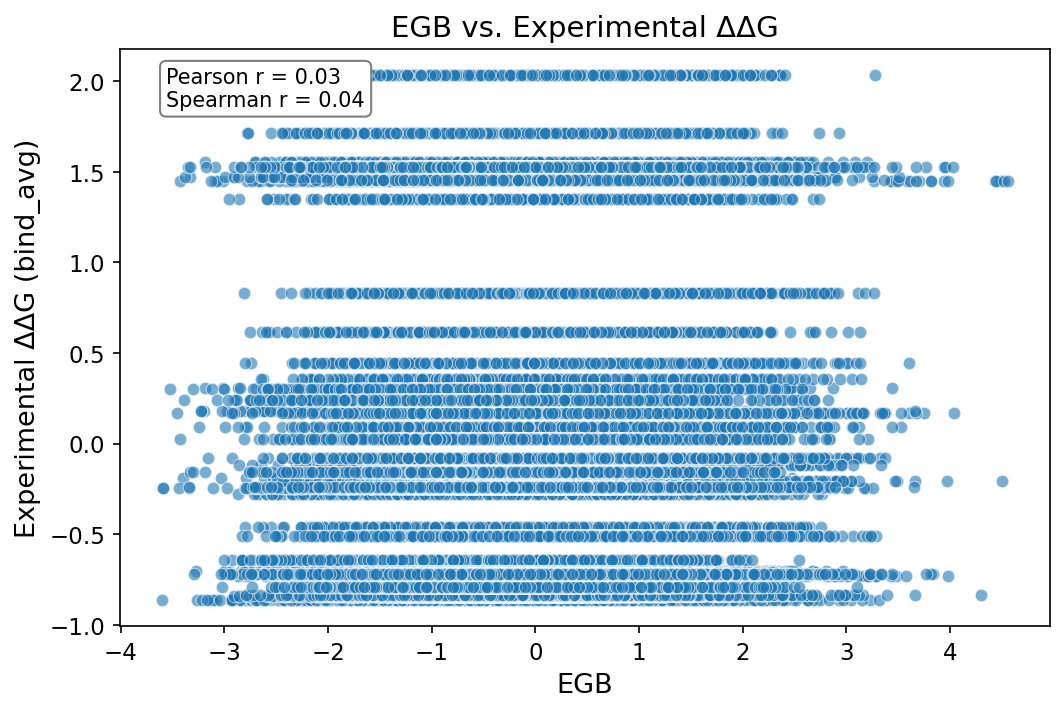

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


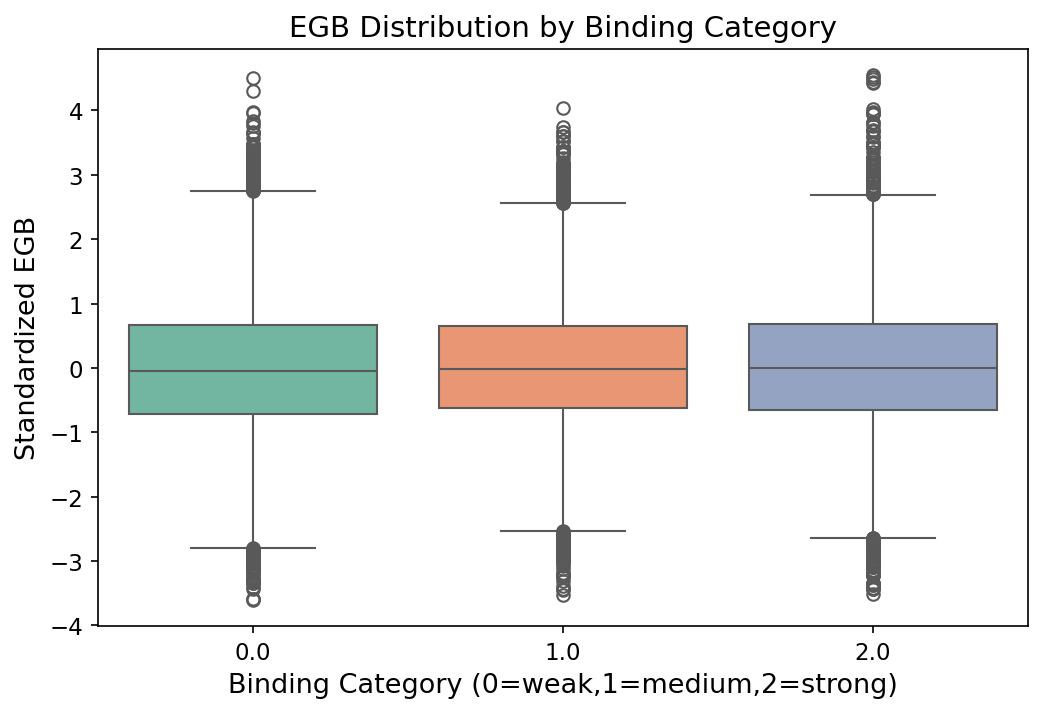

Term: EGB
 • Avg. bootstrapped KW p-value: 4.753e-01
 • Full KW H-stat=34.39, p-value=3.406e-08, η²=0.000
--------------------------------------------------


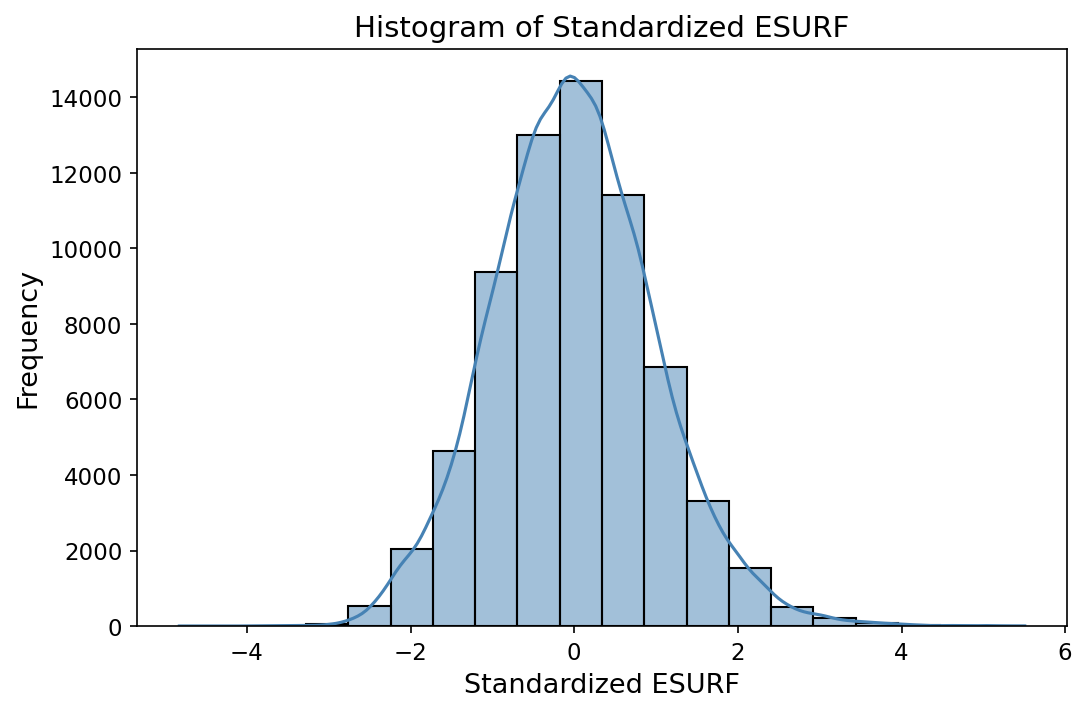

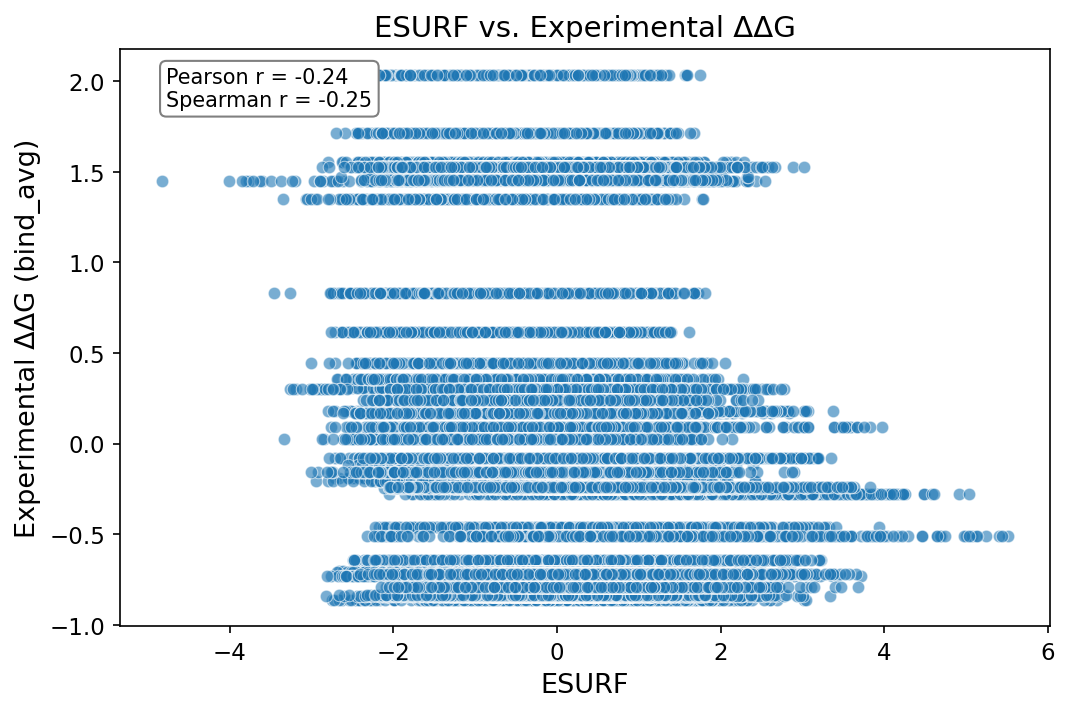

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


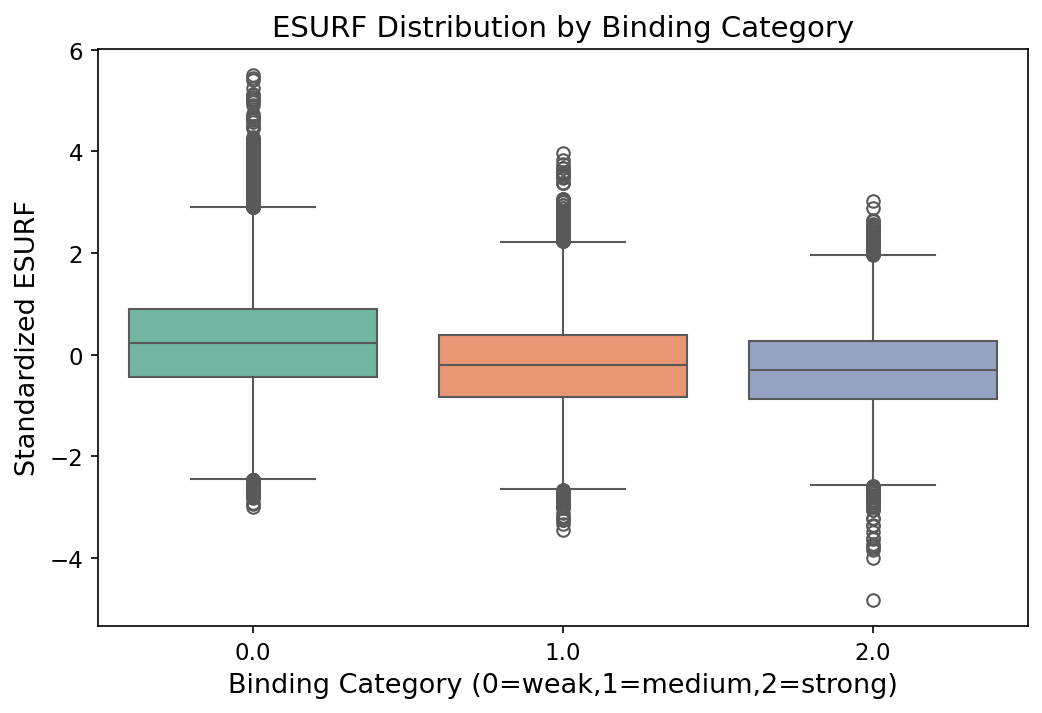

Term: ESURF
 • Avg. bootstrapped KW p-value: 7.665e-10
 • Full KW H-stat=4082.53, p-value=0.000e+00, η²=0.060
--------------------------------------------------


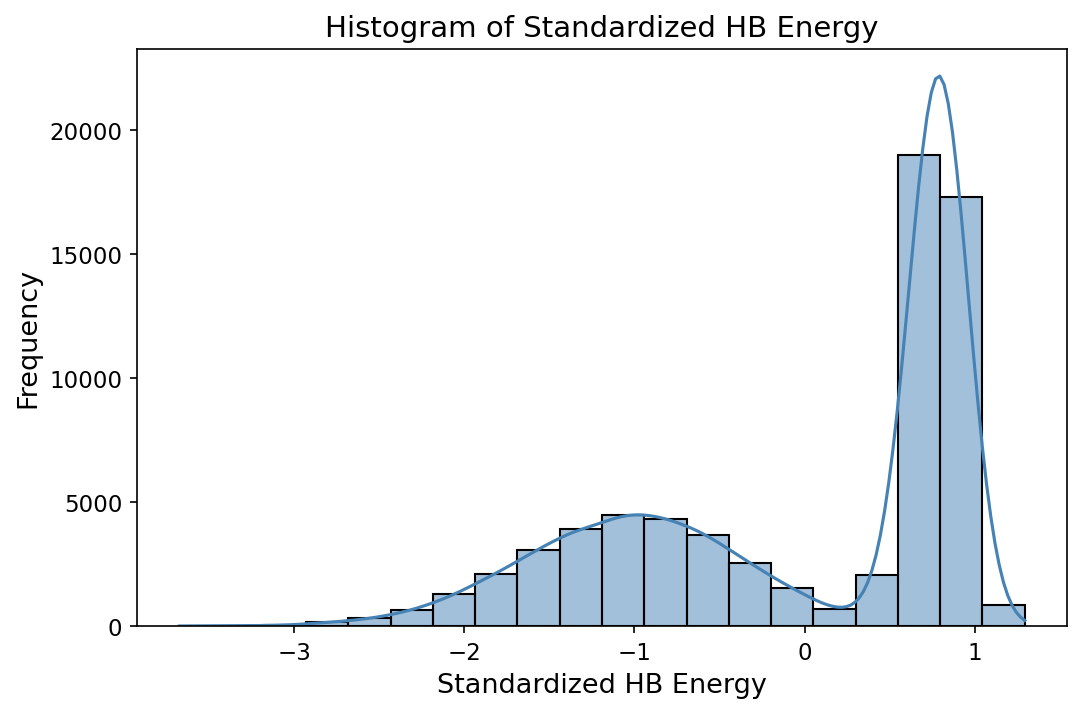

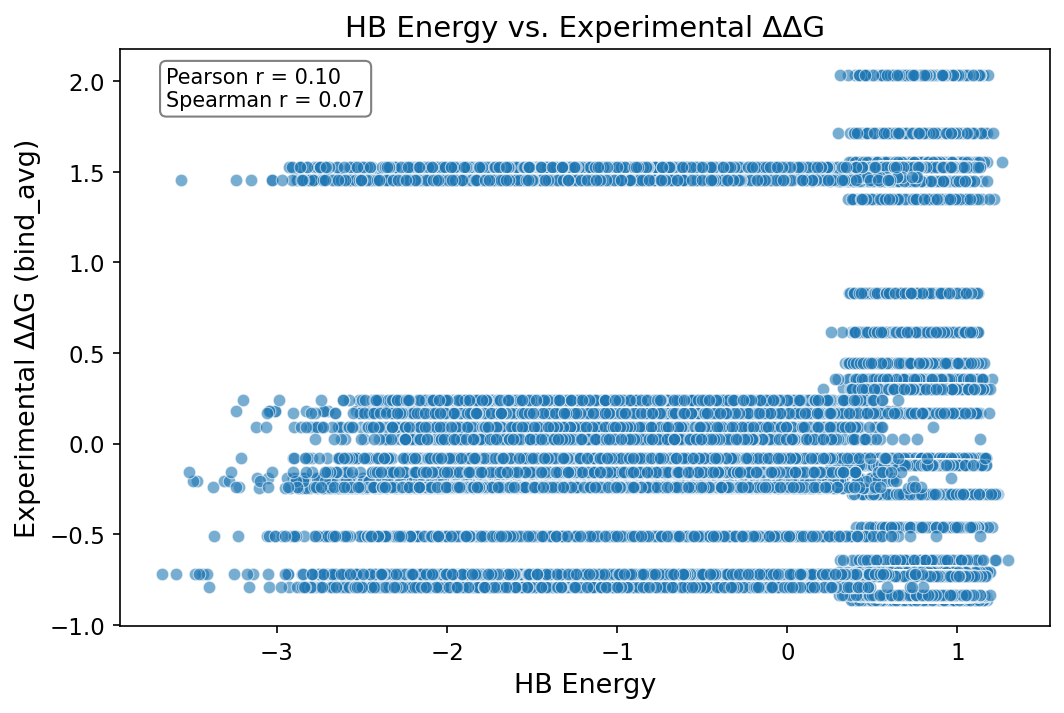

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


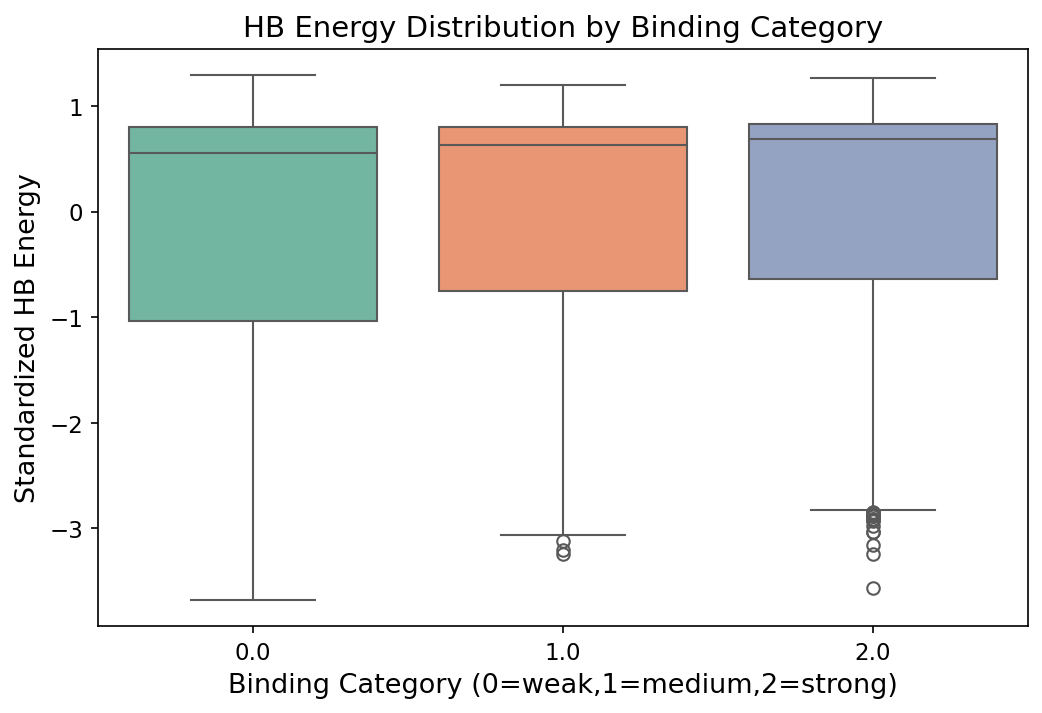

Term: HB Energy
 • Avg. bootstrapped KW p-value: 3.046e-02
 • Full KW H-stat=518.45, p-value=2.624e-113, η²=0.008
--------------------------------------------------


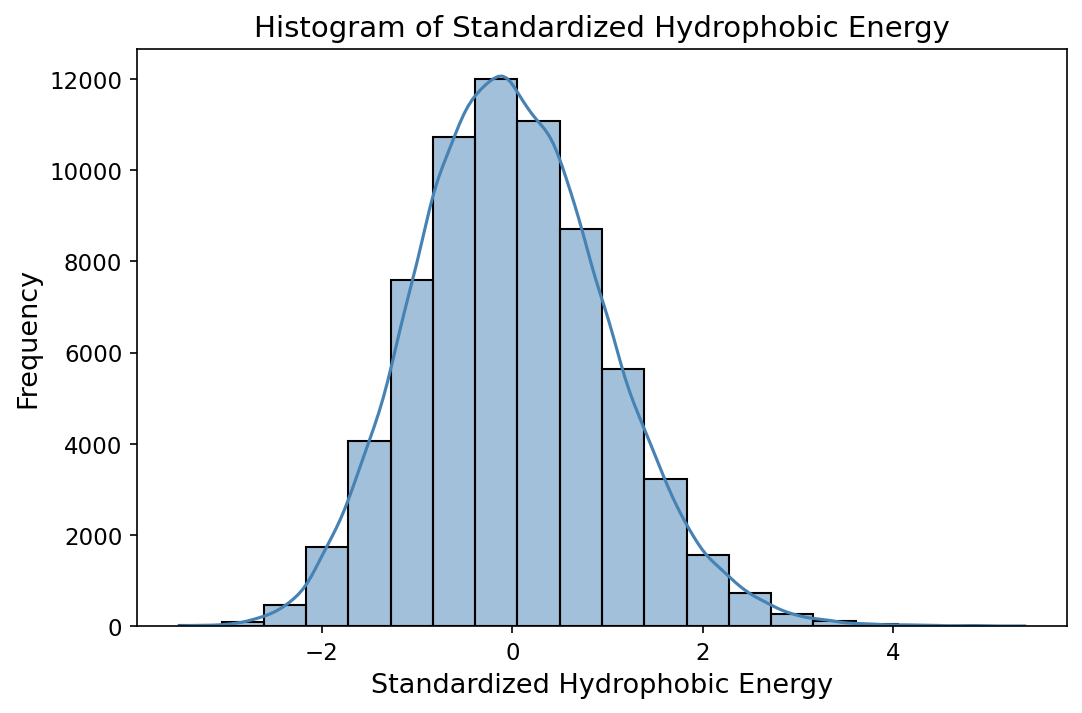

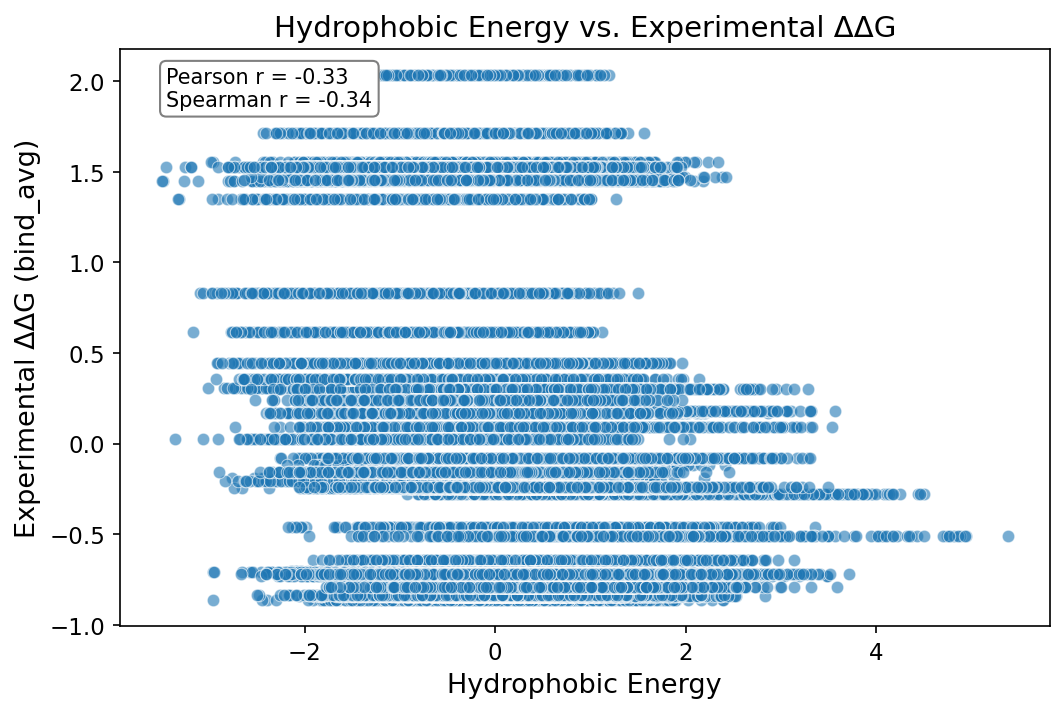

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


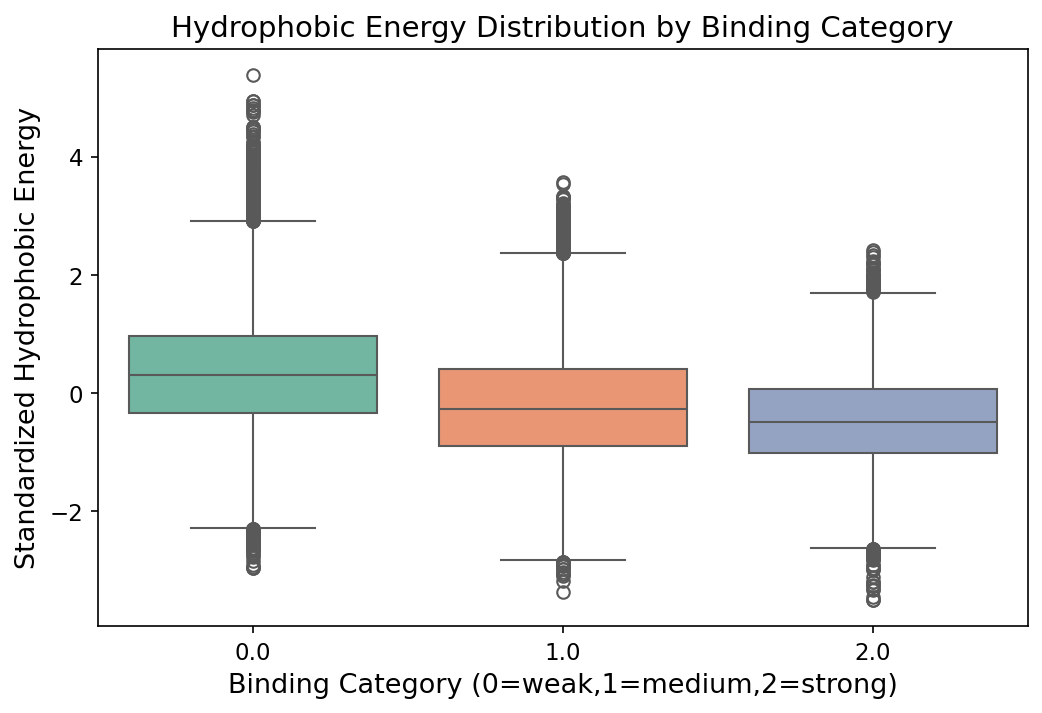

Term: Hydrophobic Energy
 • Avg. bootstrapped KW p-value: 4.541e-30
 • Full KW H-stat=7851.43, p-value=0.000e+00, η²=0.115
--------------------------------------------------


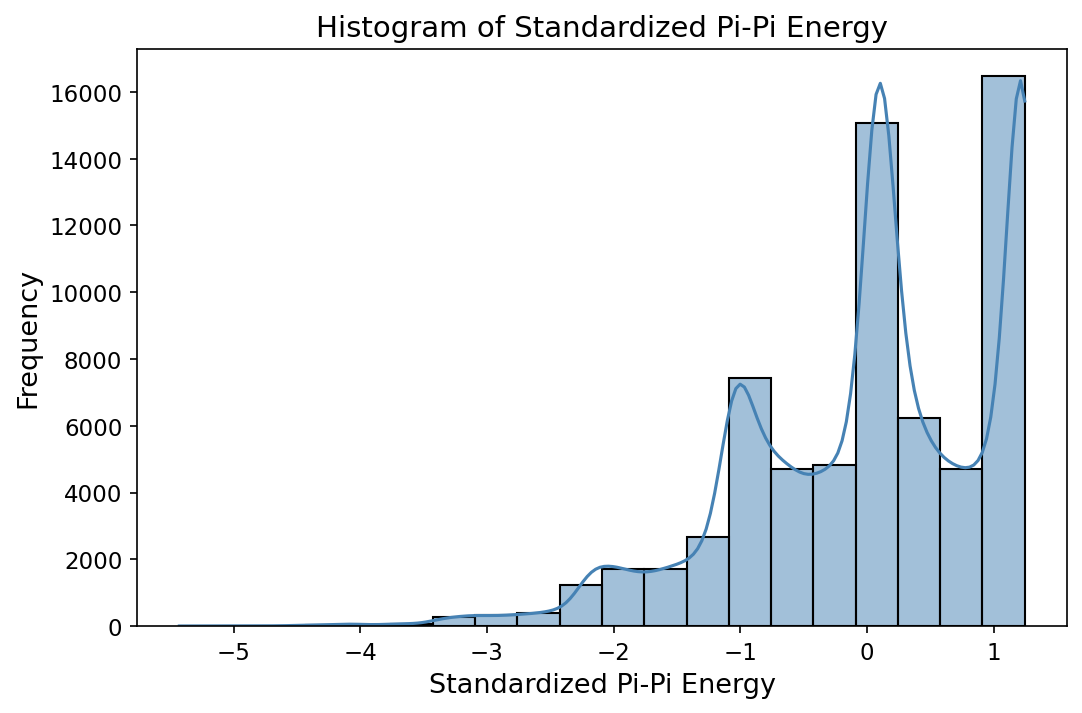

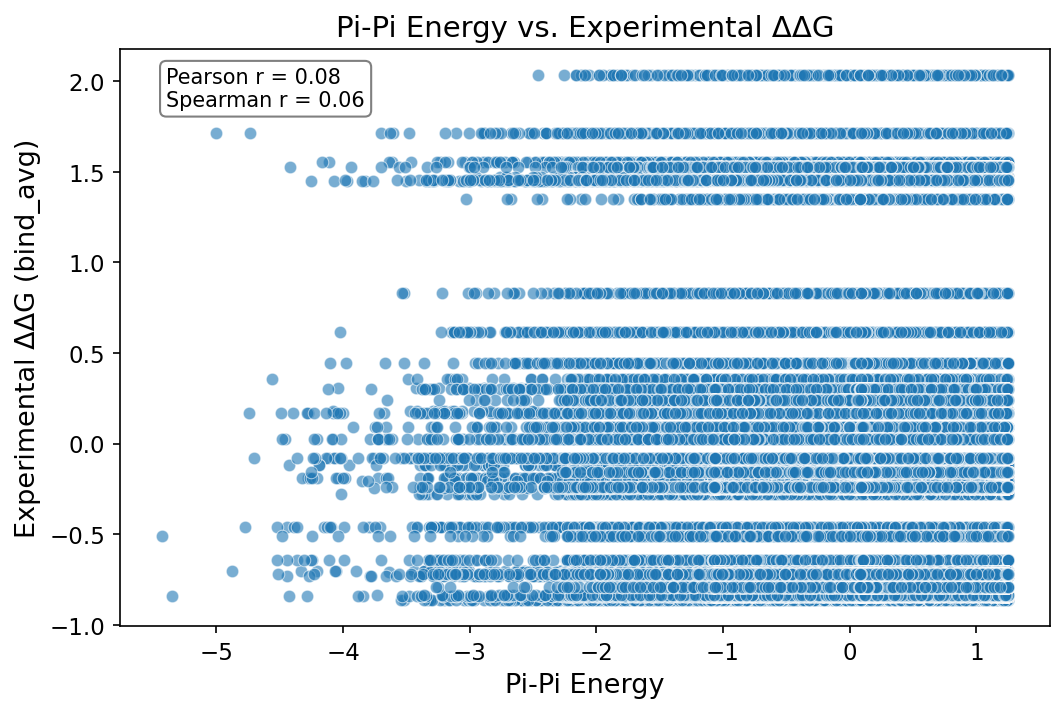

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


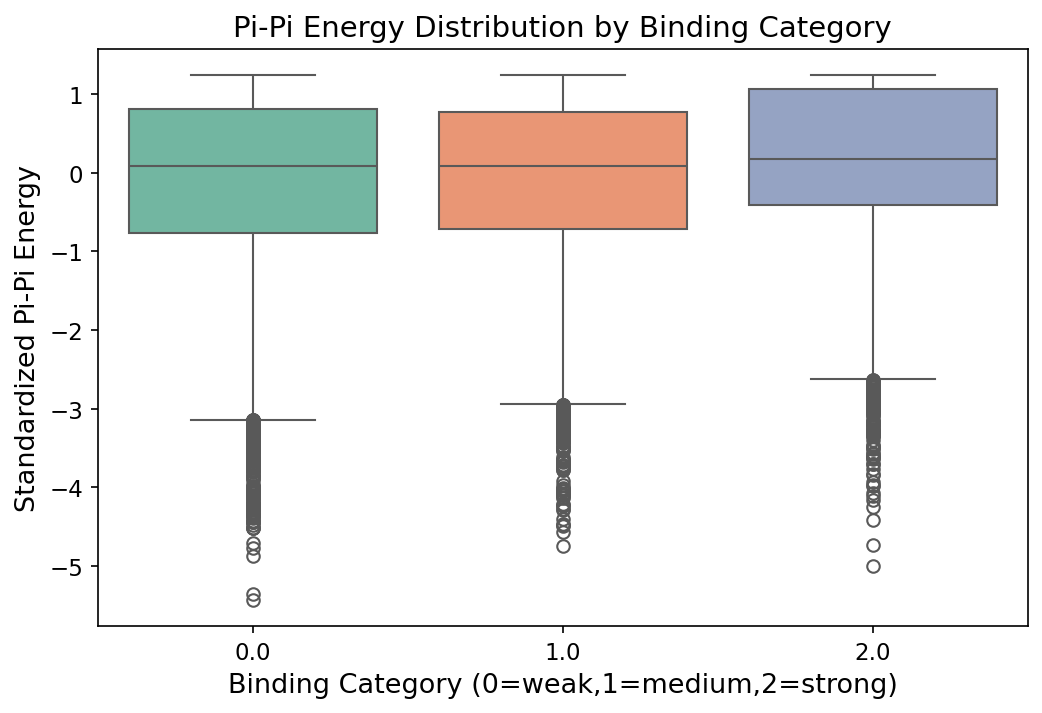

Term: Pi-Pi Energy
 • Avg. bootstrapped KW p-value: 1.480e-02
 • Full KW H-stat=442.03, p-value=1.034e-96, η²=0.006
--------------------------------------------------


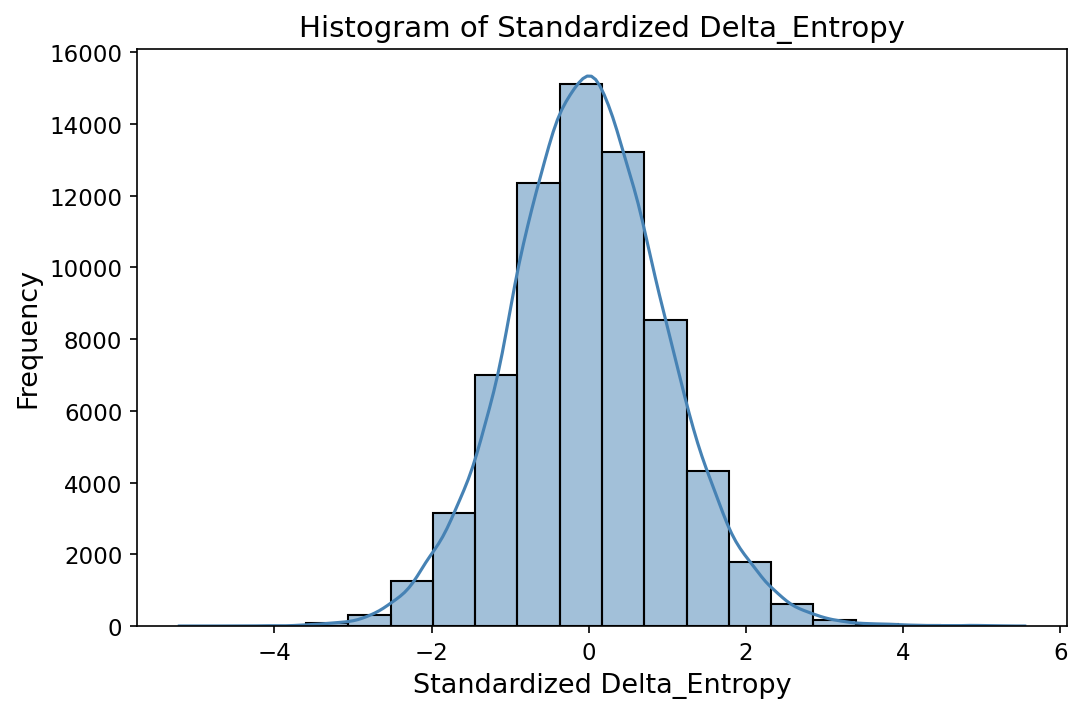

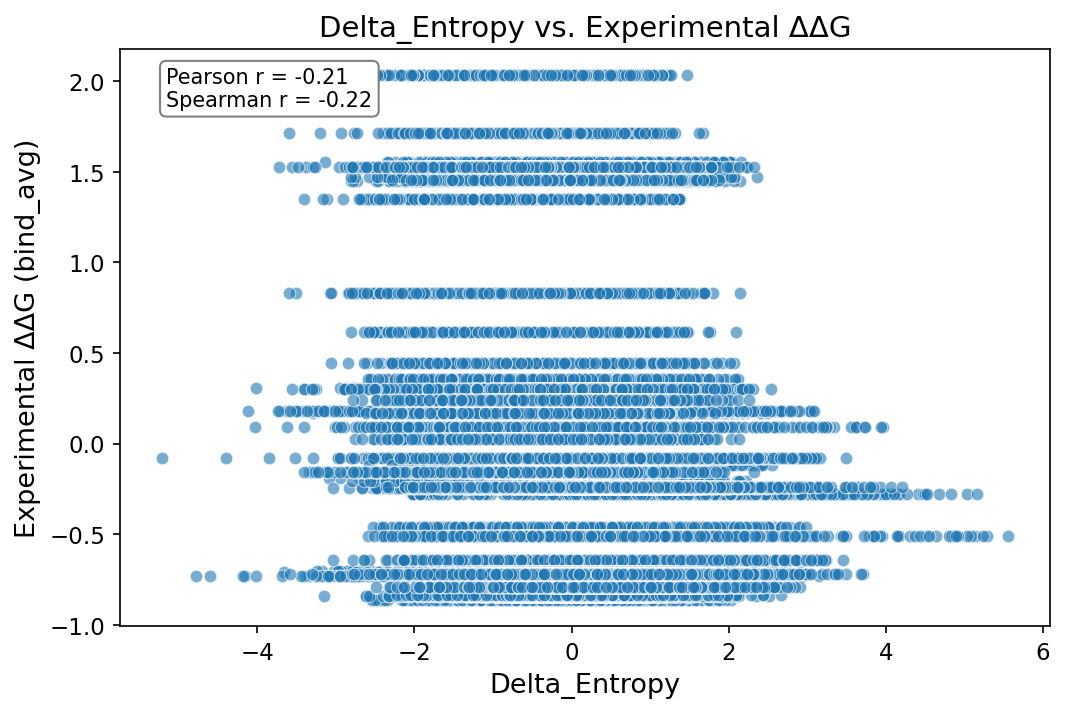

/var/folders/d3/k34hg6v522x_qvcr7lwxt2yc0000gn/T/ipykernel_80135/670133172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")


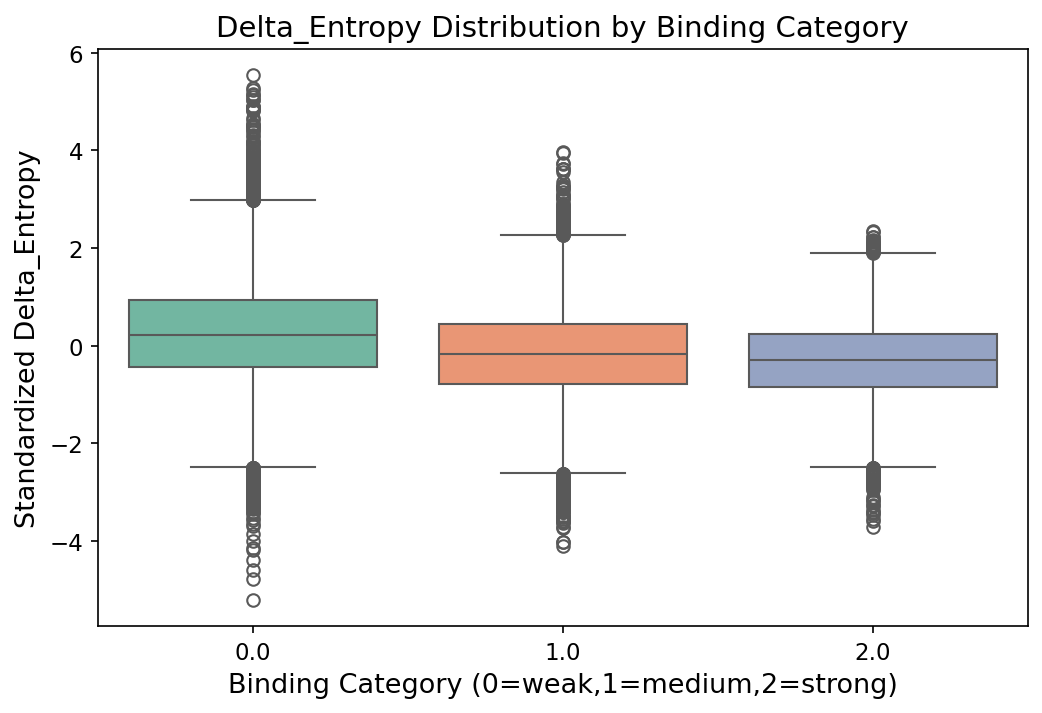

Term: Delta_Entropy
 • Avg. bootstrapped KW p-value: 4.250e-12
 • Full KW H-stat=3981.57, p-value=0.000e+00, η²=0.058
--------------------------------------------------


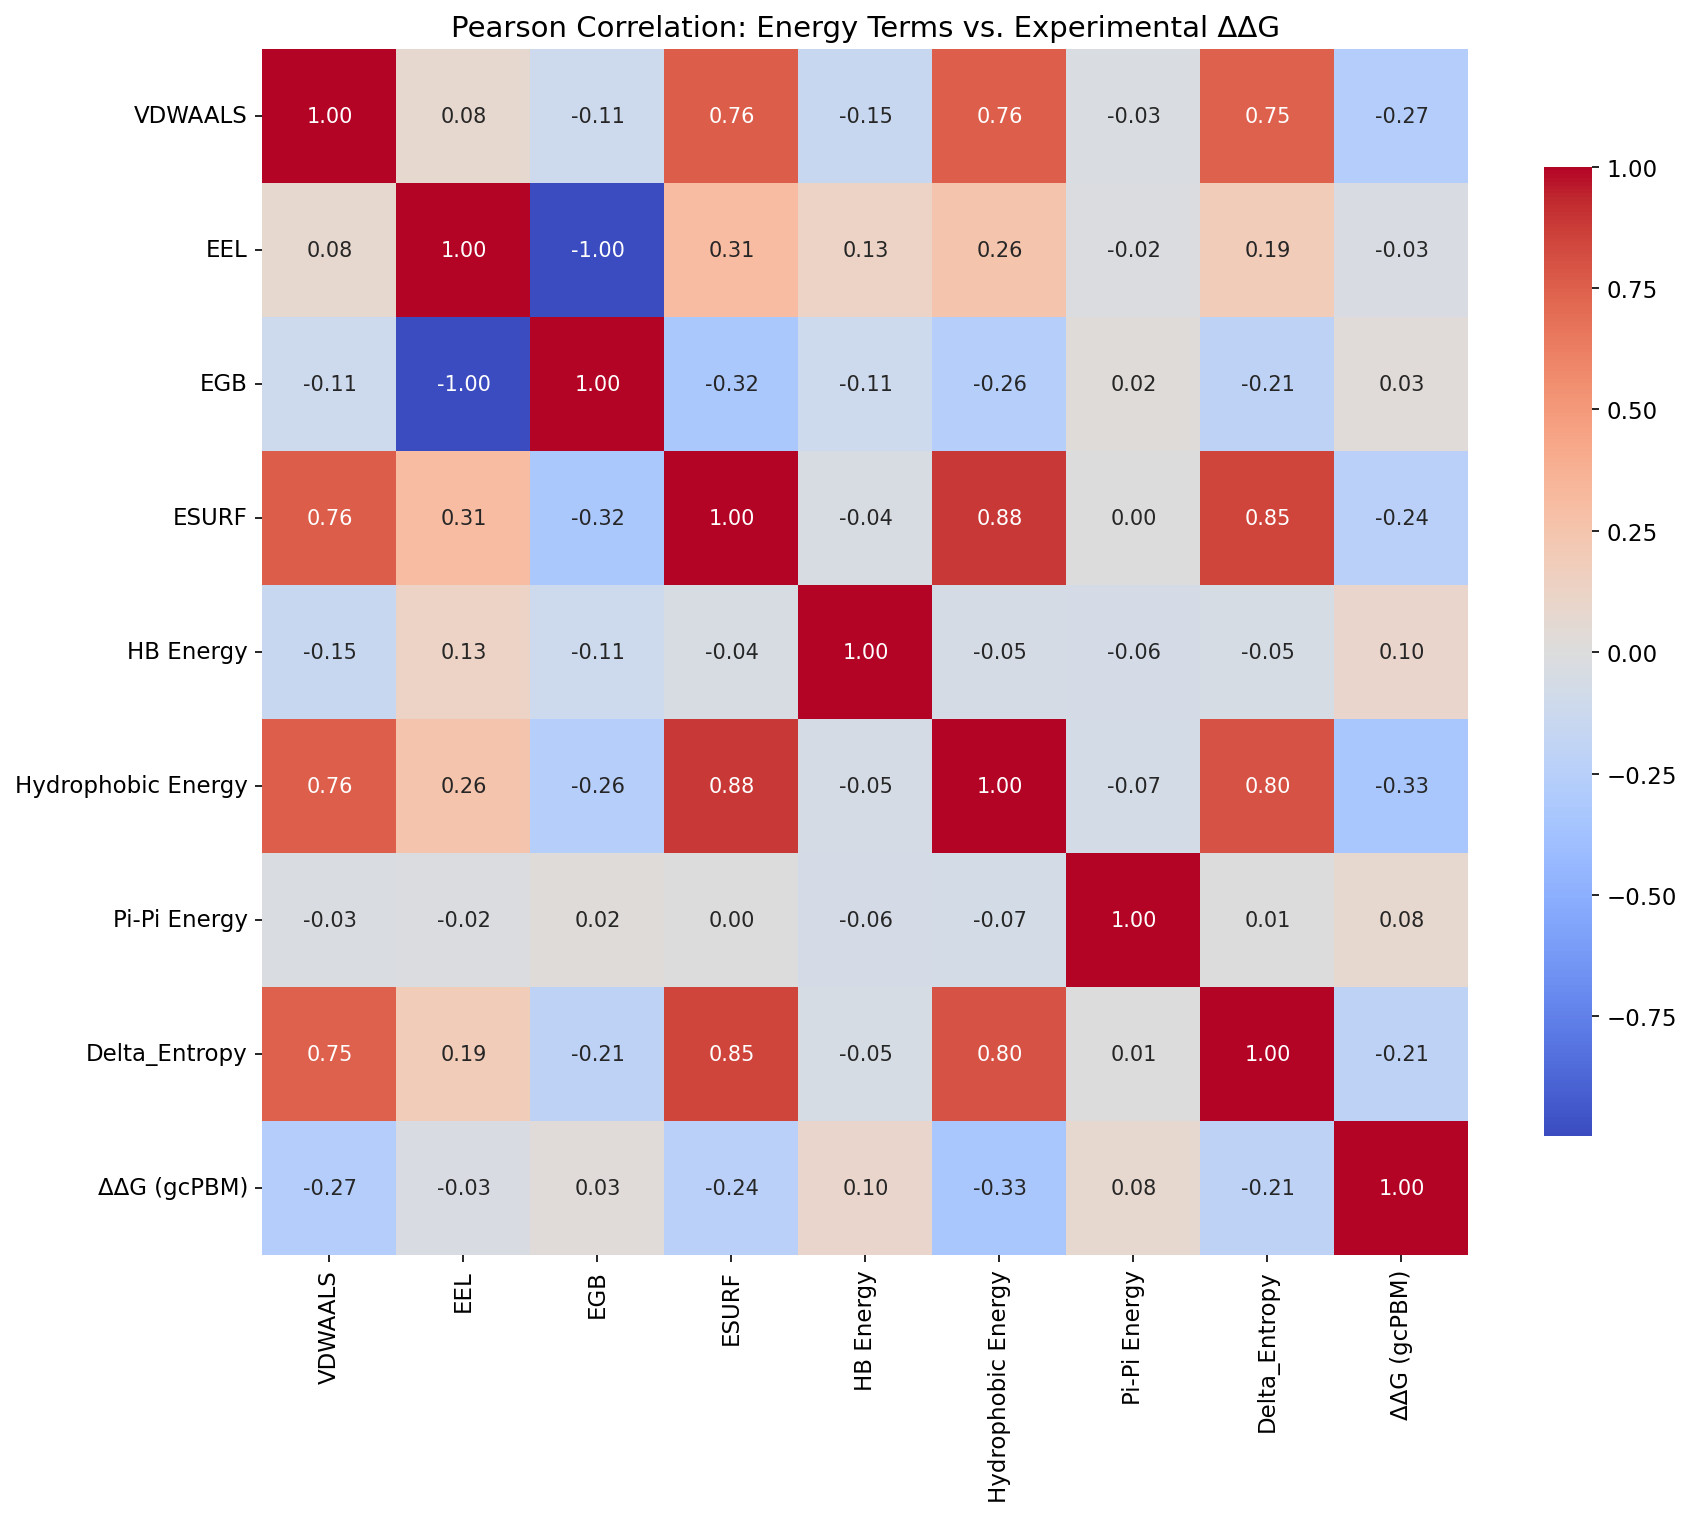

In [14]:
# 1) Load and merge computed vs. experimental data
# ------------------------------------------------
test1 = pd.read_csv("rawdat.csv")  
# Strip off any prefix in the sequence column
test1["sequence"] = test1["sequence"].str.replace("MycMax_", "", regex=False)

test2 = pd.read_csv("exp_data_all.csv")  
# Merge on the 'sequence' key, bringing in bind_avg, binding_type, etc.
df = pd.merge(test1, test2, on="sequence", how="left")

# Drop any sequences without experimental data
df = df.dropna()

# 2) Function to compute η² effect size from Kruskal–Wallis H
# -------------------------------------------------------------
def eta_squared(kruskal_stat, num_groups, total_size):
    """
    Eta-squared estimate of effect size from a KW H-statistic.
      η² = (H - k + 1) / (N - k)
    where k = number of groups, N = total sample size.
    """
    return (kruskal_stat - num_groups + 1) / (total_size - num_groups)

# 3) Loop over each energy term in the computed data
# ---------------------------------------------------
energy_terms = test1.drop(columns=['sequence','run']).columns

for term in energy_terms:
    # a) Standardize this term (zero mean, unit variance)
    std_col = f"{term} (std)"
    df[std_col] = (df[term] - df[term].mean()) / df[term].std()

    # --- 3.1) Histogram of standardized values
    plt.figure(figsize=(8, 5), dpi=150)
    sns.histplot(df[std_col], bins=20, kde=True, color="steelblue")
    plt.xlabel(f"Standardized {term}")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Standardized {term}")
    plt.show()

    # --- 3.2) Scatter vs. bind_avg (with correlation coefficients)
    plt.figure(figsize=(8, 5), dpi=150)
    sns.scatterplot(x=df[std_col], y=df["bind_avg"], alpha=0.6)
    plt.xlabel(term)
    plt.ylabel("Experimental ΔΔG (bind_avg)")
    plt.title(f"{term} vs. Experimental ΔΔG")

    r_pearson, _ = pearsonr(df[std_col], df["bind_avg"])
    r_spearman, _ = spearmanr(df[std_col], df["bind_avg"])
    plt.text(
        0.05, 0.90,
        f"Pearson r = {r_pearson:.2f}\nSpearman r = {r_spearman:.2f}",
        transform=plt.gca().transAxes,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray")
    )
    plt.show()

    # --- 3.3) Boxplot distribution by binding_type (0/1/2 categories)
    plt.figure(figsize=(8, 5), dpi=150)
    sns.boxplot(x=df["binding_type"], y=df[std_col], palette="Set2")
    plt.xlabel("Binding Category (0=weak,1=medium,2=strong)")
    plt.ylabel(f"Standardized {term}")
    plt.title(f"{term} Distribution by Binding Category")
    plt.show()

    # --- 3.4) Bootstrapped Kruskal–Wallis tests
    p_vals = []
    for _ in range(100):
        # sample up to 500 per class to balance
        sampled = df.groupby("binding_type").sample(
            n=min(500, len(df)), 
            random_state=np.random.randint(0,1e6)
        )
        groups = [
            sampled[sampled["binding_type"]==bt][term]
            for bt in sampled["binding_type"].unique()
        ]
        h_stat, p_val = kruskal(*groups)
        p_vals.append(p_val)
    avg_p = np.mean(p_vals)

    # full-dataset Kruskal–Wallis
    full_groups = [
        df[df["binding_type"]==bt][term]
        for bt in df["binding_type"].unique()
    ]
    h_full, p_full = kruskal(*full_groups)
    η2 = eta_squared(h_full, len(full_groups), len(df))

    print(f"Term: {term}")
    print(f" • Avg. bootstrapped KW p-value: {avg_p:.3e}")
    print(f" • Full KW H-stat={h_full:.2f}, p-value={p_full:.3e}, η²={η2:.3f}")
    print("-"*50)

# 4) Correlation Heatmap of all standardized energy terms vs. experimental ΔΔG
# -----------------------------------------------------------------------------
# Build list of standardized columns that exist in df
std_cols = [f"{t} (std)" for t in energy_terms]
cols_for_corr = [c for c in std_cols + ["bind_avg"] if c in df.columns]

# Compute Pearson correlation matrix
corr = df[cols_for_corr].corr(method="pearson")

# Relabel for display
label_map = {c: ("ΔΔG (gcPBM)" if c=="bind_avg" else c.replace(" (std)","")) for c in corr.columns}
corr = corr.rename(columns=label_map, index=label_map)

plt.figure(figsize=(12,10), dpi=150)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Pearson Correlation: Energy Terms vs. Experimental ΔΔG")
plt.tight_layout()
plt.show()

# Onto Machine Learning

# Protein–DNA Binding Affinity: Random Forest Baseline

This notebook demonstrates a simple workflow:
1. Load and merge computed features (`rawdat.csv`) with experimental labels (`exp_data_all.csv`).  
2. Split into train/test sets with cross-validation.  
3. Train a **Random Forest Regressor** on ΔΔG values.  
4. Evaluate performance and save outputs in a structured directory.


In [15]:
# --- Setup ---
import os
import pandas as pd
import numpy as np
from pathlib import Path

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Paths and identifiers
PROJECT_ROOT = "."
INPUTS_DIR = f"{PROJECT_ROOT}"
OUTPUT_DIR = f"{PROJECT_ROOT}/ML_RF_CV"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

SEQUENCE_ID = "sequence"
LABEL_COL   = "bind_avg"

FEATURE_FILES = [f"{INPUTS_DIR}/rawdat.csv"]
REFERENCE_FILE = f"{INPUTS_DIR}/exp_data_all.csv"


## Step 1. Load Data

We load the computed features (`rawdat.csv`) and experimental binding affinities (`exp_data_all.csv`).  
We merge them on the **sequence** column.  


In [16]:
# Load feature data
features = pd.read_csv(FEATURE_FILES[0])
features[SEQUENCE_ID] = features[SEQUENCE_ID].str.replace("MycMax_", "", regex=False)

# Load reference labels
labels = pd.read_csv(REFERENCE_FILE)

# Merge
df = pd.merge(features, labels, on=SEQUENCE_ID, how="inner")
df = df.dropna(subset=[LABEL_COL])
print("Data shape:", df.shape)
df.head()


Data shape: (68040, 13)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg,binding_type,improving
0,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-236.997,-1869.660,1823.216,-35.292,-2.590101,-156.445725,-4.282747,-24.750849,0.166339,1,0
1,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-218.620,-1850.331,1807.831,-32.521,-2.977171,-142.709472,-7.240534,-25.235404,0.166339,1,0
2,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-232.611,-1878.075,1834.181,-34.170,-3.105868,-145.088977,-8.856276,-25.124940,0.166339,1,0
3,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-203.677,-1870.595,1823.641,-32.402,-3.414769,-150.961716,-5.338670,-23.079573,0.166339,1,0
4,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-212.279,-1864.730,1820.462,-31.858,-3.571942,-146.583284,-7.171679,-22.812241,0.166339,1,0


## Step 2. Define Features and Labels

We separate the input features (X) from the target variable (y = ΔΔG).  


In [35]:
# Drop non-numeric cols (keep only usable features)
X = df.drop(columns=[SEQUENCE_ID, LABEL_COL, 'binding_type', 'improving'])
y = df[LABEL_COL]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (68040, 9)
Target shape: (68040,)


## Step 3. Train/Test Split

We do a simple 80/20 split for clarity first.  


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (54432, 9) Test size: (13608, 9)


## Step 4. Cross-Validation Setup

We’ll use 5-fold cross-validation to estimate model generalization.  


In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


## Step 5. Random Forest Model

We initialize a Random Forest Regressor with **basic hyperparameters**:  
- `n_estimators=200` → number of trees  
- `max_depth=15` → limits tree depth (prevents overfitting)  
- `min_samples_split=5` → split only if ≥5 samples  
- `min_samples_leaf=3` → ensures leaves have ≥3 samples  
- `n_jobs=-1` → use all CPU cores  


In [38]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)


## Step 6. Cross-Validation Performance
We compute mean R² and RMSE across folds.  


In [39]:
scores_r2 = cross_val_score(rf, X, y, cv=kf, scoring="r2")
scores_mse = cross_val_score(rf, X, y, cv=kf, scoring="neg_mean_squared_error")

print("CV R² scores:", scores_r2)
print("Mean R²:", np.mean(scores_r2))

print("CV RMSE scores:", np.sqrt(-scores_mse))
print("Mean RMSE:", np.mean(np.sqrt(-scores_mse)))


CV R² scores: [0.20641976 0.20387317 0.19049017 0.19288158 0.19661226]
Mean R²: 0.19805538876199477
CV RMSE scores: [0.74234563 0.74784186 0.75356551 0.74742966 0.74549505]
Mean RMSE: 0.747335543747124


## Step 7. Final Train/Test Fit and Evaluation

We train on the training split and evaluate on the holdout test set.  


In [40]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Test R²: 0.20715003867512738
Test RMSE: 0.7420039896161159


## Step 8. Save Outputs

We save the trained model and predictions into the `ML_RF_CV` directory.  


In [41]:
import joblib

In [42]:
# Save model
model_path = f"{OUTPUT_DIR}/rf_model.pkl"
joblib.dump(rf, model_path)

# Save predictions
pred_df = pd.DataFrame({
    SEQUENCE_ID: df.loc[X_test.index, SEQUENCE_ID],
    "y_true": y_test,
    "y_pred": y_pred
})
pred_df.to_csv(f"{OUTPUT_DIR}/rf_predictions.csv", index=False)

print("Saved model ->", model_path)
print("Saved predictions -> rf_predictions.csv")

Saved model -> ./ML_RF_CV/rf_model.pkl
Saved predictions -> rf_predictions.csv


# Playing with our model

Adding:
* data audit & leakage checks
* baseline (mean) predictor for context
* CV metrics (R² / RMSE / MAE)
* prediction scatter & residual diagnostics
* impurity feature importance (+ CSV)
* permutation importance on the test set (+ CSV)
* partial dependence plots (top 3 features)
* learning curve
* out-of-fold predictions (cross\_val\_predict)
* quick RandomizedSearchCV for RF hyperparams
* saving metrics/config/models/predictions to a clean output dir


Reviewing our directories for being mindful of i/o locations

In [43]:
print(f"Inputs dir: {INPUTS_DIR}")
print(f"Outputs dir: {OUTPUT_DIR}")
print(f"Feature file(s): {FEATURE_FILES}")
print(f"Reference file: {REFERENCE_FILE}")

Inputs dir: .
Outputs dir: ./ML_RF_CV
Feature file(s): ['./rawdat.csv']
Reference file: ./exp_data_all.csv


In [44]:
# Load feature data
features = pd.read_csv(FEATURE_FILES[0])

print(features)

                                    sequence  run  VDWAALS       EEL  \
0       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC    9 -252.110 -1886.830   
1       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC    9 -238.510 -1881.424   
2       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC    9 -246.721 -1895.687   
3       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC    9 -235.671 -1857.573   
4       GCGCTGGGAGGCGAACACGTGCCCGCCGCCCCATCC    9 -230.214 -1897.268   
...                                      ...  ...      ...       ...   
272155  TTTTTTTTTTTTTTGAGAAAATGAAGACAATTATCT   20 -148.291 -1941.978   
272156  TTTTTTTTTTTTTTGAGAAAATGAAGACAATTATCT   20 -142.375 -1959.709   
272157  TTTTTTTTTTTTTTGAGAAAATGAAGACAATTATCT   20 -167.433 -1911.650   
272158  TTTTTTTTTTTTTTGAGAAAATGAAGACAATTATCT   20 -136.663 -1920.439   
272159  TTTTTTTTTTTTTTGAGAAAATGAAGACAATTATCT   20 -146.999 -1929.330   

             EGB   ESURF  HB Energy  Hydrophobic Energy  Pi-Pi Energy  \
0       1841.253 -36.482  -1.940432         -165.447020 -1.655

In [45]:
# (Optional) Clean sequence keys if needed—example: strip a prefix
if SEQUENCE_ID in features.columns:
    features[SEQUENCE_ID] = features[SEQUENCE_ID].astype(str).str.replace("MycMax_", "", regex=False)

In [46]:
# Load labels
labels = pd.read_csv(REFERENCE_FILE)

print(labels)

                                 sequence  bind_avg  binding_type  improving
0    GTACACAATTTTTTACAAAATTTAAATTAAAACAAA -0.862667             0          1
1    GCAGCCGAGGCGGAGAGAGAGAGAGGACAGCTTACG -0.703319             0          1
2    AGGCCCAGGAAGAACAATGGCTCTGCCAACTGGGCA -0.659464             0          1
3    CTTCCTCACCTGCAGACTTCCTTCCCTGAGTCCCAG -0.543823             0          1
4    TGAGGGTCAGAGGCACCCCTTCCTGGAATCTCCTTC -0.424828             0          1
..                                    ...       ...           ...        ...
163  ATCTCCTGGGGCGACCACGAGGTCACCCGTCCAGGT  1.524243             2          0
164  GAAAACCAGCGAGACCGCATGGTCTCACTTATAAGT  1.452711             2          0
165  AGGGAGTTCTCACACCATGTGGGTGGGATTGTAACT  1.305160             2          0
166  ACACTGAGCTTCCTCCACGTGCCCAGGTCCTGGCAG  1.430431             2          0
167  GTGTCTCCATTGGGGCACGTGTTTATATGTTTATAA  1.598717             2          0

[168 rows x 4 columns]


In [47]:
# Keep rows with non-null labels
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)

print("Merged shape:", df.shape)
display(df.head(3))

Merged shape: (68040, 13)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg,binding_type,improving
0,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-236.997,-1869.660,1823.216,-35.292,-2.590101,-156.445725,-4.282747,-24.750849,0.166339,1,0
1,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-218.620,-1850.331,1807.831,-32.521,-2.977171,-142.709472,-7.240534,-25.235404,0.166339,1,0
2,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-232.611,-1878.075,1834.181,-34.170,-3.105868,-145.088977,-8.856276,-25.124940,0.166339,1,0


In [48]:
print("\nDataFrame info:")
df.info()

print("\nMissing values per column (top 20):")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68040 entries, 0 to 68039
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sequence            68040 non-null  object 
 1   run                 68040 non-null  int64  
 2   VDWAALS             68040 non-null  float64
 3   EEL                 68040 non-null  float64
 4   EGB                 68040 non-null  float64
 5   ESURF               68040 non-null  float64
 6   HB Energy           68040 non-null  float64
 7   Hydrophobic Energy  68040 non-null  float64
 8   Pi-Pi Energy        68040 non-null  float64
 9   Delta_Entropy       68040 non-null  float64
 10  bind_avg            68040 non-null  float64
 11  binding_type        68040 non-null  int64  
 12  improving           68040 non-null  int64  
dtypes: float64(9), int64(3), object(1)
memory usage: 6.7+ MB

Missing values per column (top 20):


sequence              0
run                   0
VDWAALS               0
EEL                   0
EGB                   0
ESURF                 0
HB Energy             0
Hydrophobic Energy    0
Pi-Pi Energy          0
Delta_Entropy         0
bind_avg              0
binding_type          0
improving             0
dtype: int64

In [49]:
# Duplicate sequences
dup_count = df.duplicated(subset=[SEQUENCE_ID]).sum()
print(f"\nDuplicate {SEQUENCE_ID} rows:", dup_count)

print("\nDescriptive stats (numeric):")
display(df.describe().T.head(15))


Duplicate sequence rows: 67998

Descriptive stats (numeric):


,count,mean,std,min,25%,50%,75%,max
run,68040.0,10.500000,5.766324,1.000000,5.750000,10.500000,15.250000,20.000000
VDWAALS,68040.0,-201.378166,20.130228,-270.351000,-215.101000,-201.824000,-188.088000,-105.281000
EEL,68040.0,-1898.996636,38.450855,-2076.822000,-1924.672000,-1897.880000,-1873.026000,-1758.701000
EGB,68040.0,1850.679788,35.684319,1722.168000,1826.616000,1849.566000,1874.488000,2013.174000
ESURF,68040.0,-31.474066,2.393914,-43.027000,-33.082000,-31.535000,-29.954000,-18.292000
HB Energy,68040.0,-8.175591,6.065805,-30.470945,-13.585766,-4.378422,-3.275576,-0.324696
Hydrophobic Energy,68040.0,-135.669642,13.021100,-181.225207,-144.756364,-136.267018,-127.247098,-65.594027
Pi-Pi Energy,68040.0,-3.219995,2.584144,-17.248618,-4.999256,-2.974733,-0.964479,0.000000
Delta_Entropy,68040.0,-21.768632,2.156622,-33.004332,-23.182778,-21.798697,-20.392486,-9.803474
bind_avg,68040.0,0.182705,0.834584,-0.862667,-0.511587,-0.027842,0.614097,2.035660
